# Ujain Akhir Semester Bengkel Koding

# Nama : Salsa Seva Yuliana 
# Nim  : A11.2022.14672

## Latar Belakang

Churn pelanggan adalah kondisi ketika seorang pelanggan berhenti menggunakan layanan atau tidak lagi melakukan aktivitas pembelian. Masalah ini sangat penting dalam bidang bisnis dan pemasaran karena tingkat churn yang tinggi dapat menurunkan pendapatan perusahaan serta meningkatkan biaya untuk mendapatkan pelanggan baru. Oleh karena itu, kemampuan memprediksi pelanggan mana yang berpotensi churn menjadi hal yang sangat dibutuhkan. 

## Dataset 1. Sumber data awal: Sales and Marketing Dataset 2. Link: https://www.kaggle.com/datasets/bhaskerpaul/sales-and-marketing-dataset 

### install dependensi

In [1]:
# import sys
# import subprocess

# Memaksa instalasi pembaruan scikit-learn langsung dari dalam sistem inti Python kernel
# subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "scikit-learn"])
# print("Proses upgrade scikit-learn selesai dengan sukses!")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Mengatur tema visualisasi agar rapi saat di-render di VS Code
sns.set_theme(style="whitegrid")

### Load Dataset (Membaca File), mengunduh langsung dari kaggle dan load dataset

In [3]:
import kagglehub
import pandas as pd
import os

print("Sedang mengunduh dataset dari Kaggle...")

# 1. Download folder dataset ke local cache
folder_path = kagglehub.dataset_download("bhaskerpaul/sales-and-marketing-dataset")
print(f"Dataset berhasil diunduh ke: {folder_path}")

# 2. Trik otomatis mencari file .csv yang ada di dalam folder tersebut
isi_folder = os.listdir(folder_path)
files_csv = [f for f in isi_folder if f.endswith('.csv')]

# 3. Validasi dan baca datanya jika file CSV ditemukan
if files_csv:
    file_name = files_csv[0] # Mengambil file CSV pertama yang ditemukan
    full_path = os.path.join(folder_path, file_name)
    
    # Membaca data menggunakan pandas
    df = pd.read_csv(full_path)
    
    print("\n=== DATASET BERHASIL DI-LOAD VIA KAGGLEHUB ===")
    print(f"Nama File Asli    : {file_name}")
    print(f"Total Sampel Data : {df.shape[0]} records")
    print(f"Total Fitur/Kolom  : {df.shape[1]} kolom")
else:
    print("\n[ERROR] Waduh, tidak ditemukan file format .csv di folder tersebut!")
    print(f"Isi folder unduhan saat ini: {isi_folder}")

Sedang mengunduh dataset dari Kaggle...
Dataset berhasil diunduh ke: C:\Users\TUF Gaming - FX506HF\.cache\kagglehub\datasets\bhaskerpaul\sales-and-marketing-dataset\versions\1

=== DATASET BERHASIL DI-LOAD VIA KAGGLEHUB ===
Nama File Asli    : Sales - Marketing customer dataset.csv
Total Sampel Data : 15000 records
Total Fitur/Kolom  : 30 kolom


# === Poin D1. Tugas 1 ===

#### Menampilkan 5 baris pertama, informasi dataset, dan statistik deskriptif. 

In [4]:
print("=== 5 BARIS PERTAMA DATASET ===")
display(df.head())

print("\n=== INFORMASI STRUKTUR DATASET ===")
df.info()

print("\n=== STATISTIK DESKRIPTIF FITUR NUMERIK ===")
display(df.describe())

# Menampilkan statistik deskriptif khusus untuk fitur kategorikal atau teks
print("\n=== STATISTIK DESKRIPTIF FITUR Teks ===")
df.describe(include='object')

=== 5 BARIS PERTAMA DATASET ===


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0



=== INFORMASI STRUKTUR DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64


,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000



=== STATISTIK DESKRIPTIF FITUR Teks ===


,gender,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,coupon_code,payment_method
count,14262,15000,15000,15000,15000,15000,15000,15000,8867,15000
unique,3,5,7,1000,800,5,3,2,3,5
top,Male,Germany,London,2024-09-20 00:00:00,2025-01-17 00:00:00,Organic,Tablet,Monthly,REF10,UPI
freq,6844,3072,2236,29,32,3055,5043,7666,2995,3105


### Analisis Hasil Exploratory Data Analysis (EDA) - Tahap Awal

Berdasarkan eksplorasi awal menggunakan fungsi df.head(), df.info(), dan df.describe(), berikut adalah poin-poin analisis mengenai karakteristik dataset yang digunakan:

#### 1. Struktur dan Komposisi Dataset
* Ukuran Data: Dataset ini memiliki total sampel sebanyak 15.000 baris data (records) dengan 30 kolom fitur.
* Cakupan Informasi: Fitur di dalam dataset merekam informasi komprehensif mengenai data demografis pelanggan, aktivitas penggunaan layanan, riwayat transaksi, hingga pola interaksi pelanggan dengan perusahaan.
* Variabel Target: Kolom target dalam pemodelan ini adalah churn, yang bernilai 1 untuk pelanggan yang berhenti menggunakan layanan dan 0 untuk pelanggan yang tetap aktif.
* Komposisi Tipe Data: Terdiri atas kombinasi yang seimbang antara tipe data numerik (int64 & float64) serta tipe data kategorikal/teks (object).

#### 2. Indikasi Awal Nilai Kosong (Missing Value)
Melalui perbandingan jumlah baris total (15.000) dengan nilai Non-Null Count, teridentifikasi adanya beberapa kolom penting yang tidak terisi penuh dengan rincian jumlah data kosong (missing value) sebagai berikut:
* gender: Hanya memiliki 14.262 baris valid, artinya terdapat 738 data kosong .
* age: Hanya memiliki 13.800 baris valid, artinya terdapat 1.200 data kosong .
* total_spent: Hanya memiliki 13.950 baris valid, artinya terdapat 1.050 data kosong .
* Catatan: Kolom-kolom yang mengandung nilai kosong ini wajib ditangani menggunakan teknik imputasi pada tahap preprocessing sebelum masuk ke proses modeling.

#### 3. Ringkasan Statistik & Temuan Anomali Data
* Anomali Kritis pada Fitur age: Berdasarkan deskripsi statistik, kolom age menunjukkan nilai minimum yang tidak logis yaitu -4.000000. Secara logika bisnis, usia pelanggan tidak mungkin bernilai negatif. Temuan noise/anomali ini harus dibersihkan atau diimputasi pada proses pembersihan data nanti.
* Karakteristik Umum Pelanggan:
    * Usia: Rata-rata usia pelanggan berada di angka 35 tahun (termasuk dalam kelompok usia produktif).
    * Interaksi & Aktivitas: Rata-rata total kunjungan pelanggan (total_visits) adalah 15 kali, dengan rata-rata waktu sesi penggunaan (avg_session_time) berkisar di angka 8 menit.
    * Segmentasi Premium: Sebanyak 30,4% dari total pelanggan merupakan pengguna kategori premium (is_premium_user mean = 0.304).
    * Sensitivitas Promosi: Tingkat pemanfaatan diskon (discount_use`) sangat tinggi, yaitu mencapai 49,4%. Hal ini mengindikasikan bahwa hampir setengah dari populasi pelanggan aktif merespons program promosi/potongan harga yang diberikan perusahaan.

# === Poin D1. Tugas 2 ===
# Menghitung persentase nilai kosong untuk semua kolom

#### Menghitung persentase nilai kosong (missing value) untuk semua kolom dan visualisasikan hasilnya dalam bentuk diagram batang. 

Tabel Persentase Nilai Kosong per Kolom:


,kolom,persentase_missing
0,coupon_code,40.886667
1,age,8.000000
2,total_spent,7.000000
3,gender,4.920000
4,satisfaction_score,4.680000
5,customer_id,0.000000
6,last_3_month_purchase_freq,0.000000
7,lifetime_value,0.000000
8,marketing_spend_per_user,0.000000
9,nps_score,0.000000


C:\Users\TUF Gaming - FX506HF\AppData\Local\Temp\ipykernel_6360\3761943048.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='persentase_missing', y='kolom', data=df_hilang, palette='Reds_r')


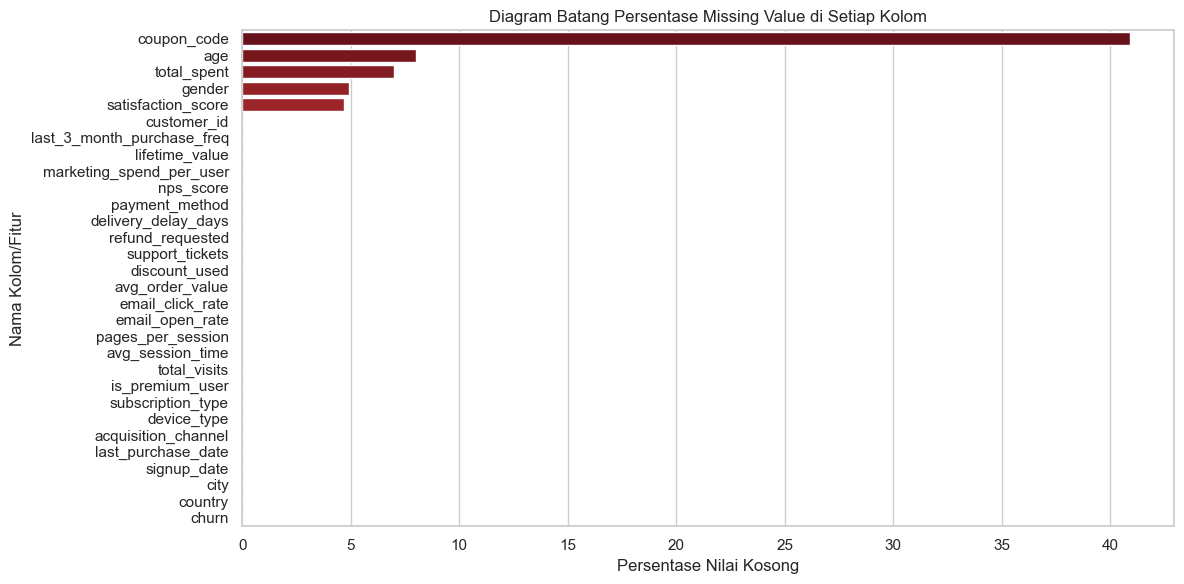

In [5]:
persentase_hilang = (df.isnull().sum() / len(df)) * 100

# untuk embuat dataframe baru untuk menyimpan hasil hitungan agar rapi
df_hilang = pd.DataFrame({
    'kolom': df.columns,
    'persentase_missing': persentase_hilang
})

# untuk engurutkan hasil dari yang paling banyak nilai kosongnya
df_hilang = df_hilang.sort_values(by='persentase_missing', ascending=False).reset_index(drop=True)

# untuk enampilkan tabel hasil hitungan persentase nilai kosong
print("Tabel Persentase Nilai Kosong per Kolom:")
display(df_hilang)

# untuk membuat visualisasi diagram batang menggunakan matplotlib dan seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x='persentase_missing', y='kolom', data=df_hilang, palette='Reds_r')
plt.title('Diagram Batang Persentase Missing Value di Setiap Kolom')
plt.xlabel('Persentase Nilai Kosong')
plt.ylabel('Nama Kolom/Fitur')
plt.tight_layout()
plt.show()

Analisis Visualisasi Nilai Kosong atau Missing Value

Berdasarkan hasil hitungan tabel dan grafik diagram batang di atas, proses pengecekan nilai kosong pada seluruh kolom dataset menghasilkan beberapa poin pengamatan sebagai berikut:

Sebagian besar fitur di dalam dataset ini sudah bersih dan terisi penuh dengan data yang valid karena nilai kosongnya berada di angka nol. Hal ini menunjukkan kualitas data yang baik untuk mayoritas variabel prediktor yang tersedia.

Namun terdapat lima kolom spesifik yang terdeteksi memiliki nilai kosong atau missing value dengan jumlah persentase yang bervariasi. Kolom-kolom tersebut harus ditangani terlebih dahulu sebelum masuk ke tahap pemodelan machine learning. Rincian persentase dan jumlah data yang hilang adalah sebagai berikut:

Kolom coupon_code menempati posisi teratas dengan jumlah data kosong paling banyak yaitu sebesar 40,88 persen atau sekitar 6133 baris data yang nilainya tidak terekam di dalam sistem dari total 15000 records.

Kolom age atau usia pelanggan berada di posisi kedua dengan persentase data kosong sebesar 8,00 persen atau sebanyak 1200 baris data.

Kolom total_spent atau total pengeluaran pelanggan memiliki data kosong sebesar 7,00 persen atau sebanyak 1050 baris data yang belum terisi penuh.

Kolom gender atau jenis kelamin pelanggan terdeteksi memiliki data kosong sebesar 4,92 persen atau sebanyak 738 baris data.

Kolom satisfaction_score atau skor kepuasan pelanggan menjadi kolom kelima yang memiliki nilai kosong dengan rincian persentase sebesar 4,68 persen atau sebanyak 702 baris data yang hilang.

Kesimpulan langkah selanjutnya adalah kelima kolom tersebut wajib melalui proses penanganan missing value pada tahap preprocessing nanti. Untuk kolom numerik seperti age, total_spent, dan satisfaction_score dapat diatasi menggunakan teknik imputasi nilai tengah atau rata-rata. Sedangkan untuk kolom kategorikal seperti gender dan coupon_code dapat diisi menggunakan nilai modus atau kategori baru khusus data kosong agar seluruh baris menjadi lengkap sebelum diproses oleh algoritma model.

# === Poin D1. Tugas 3 ===
# Menghitung jumlah data per kategori pada variabel target churn dan Membuat visualisasi diagram batang untuk distribusi kelas


### Memvisualisasikan distribusi variabel target (Churn) untuk mengetahui kondisi keseimbangan kelas menggunakan diagram batang. 

Jumlah data masing-masing kelas:
churn
0    12702
1     2298
Name: count, dtype: int64


C:\Users\TUF Gaming - FX506HF\AppData\Local\Temp\ipykernel_6360\616392090.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='Set2')


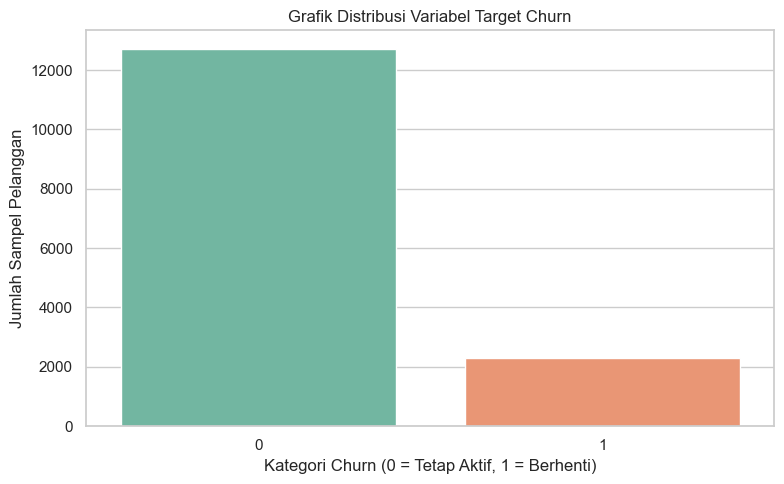

In [6]:
# Menghitung jumlah data per kategori pada variabel target churn
hitung_churn = df['churn'].value_counts()
print("Jumlah data masing-masing kelas:")
print(hitung_churn)

# Membuat visualisasi diagram batang untuk distribusi kelas
plt.figure(figsize=(8, 5))
sns.countplot(x='churn', data=df, palette='Set2')
plt.title('Grafik Distribusi Variabel Target Churn')
plt.xlabel('Kategori Churn (0 = Tetap Aktif, 1 = Berhenti)')
plt.ylabel('Jumlah Sampel Pelanggan')
plt.tight_layout()
plt.show()

Analisis Keseimbangan Kelas Variabel Target Churn

Berdasarkan grafik diagram batang yang dihasilkan, proses visualisasi pada kolom target churn dilakukan untuk mengidentifikasi apakah terdapat masalah ketidakseimbangan kelas di dalam dataset yang digunakan.

Dari hasil visualisasi tersebut, terlihat perbedaan jumlah yang sangat mencolok antara kelompok pelanggan yang tetap setia menggunakan layanan dan kelompok pelanggan yang memutuskan untuk berhenti atau churn. Berdasarkan hitungan data aktual, jumlah pelanggan yang memilih untuk tetap aktif atau berada pada kelas nol adalah sebanyak 12702 orang. Sementara itu, jumlah pelanggan yang memutuskan untuk berhenti menggunakan layanan atau berada pada kelas satu hanya sebanyak 2298 orang dari total keseluruhan 15000 records data pelanggan.

Kondisi jomplang ini mengonfirmasi bahwa dataset mengalami situasi ketidakseimbangan kelas atau class imbalance yang cukup signifikan. Porsi data sangat didominasi oleh kelompok pelanggan yang loyal atau setia, sedangkan data mengenai pelanggan yang melakukan churn berjumlah jauh lebih sedikit.

Kesimpulan langkah selanjutnya adalah fenomena ketidakseimbangan ini harus ditangani dengan tepat sebelum masuk ke tahap training model. Jika data dibiarkan pincang seperti ini, algoritma machine learning akan cenderung mengalami bias di mana model menjadi sangat akurat dalam memprediksi pelanggan yang aktif namun gagal mendeteksi pelanggan yang sebenarnya berpotensi akan berhenti atau churn. Oleh karena itu, pada tahap preprocessing nanti perlu dipertimbangkan penerapan teknik penyeimbangan data seperti metode oversampling smote atau undersampling agar model dapat mengenali karakteristik kedua kelas secara seimbang.

# === Poin D1. Tugas 4 ===
### Membuat heatmap korelasi untuk fitur numerik dalam dataset dan identifikasi hubungan antar variabel yang berpotensi mempengaruhi pola churn pelanggan. 

#### Membuat heatmap korelasi untuk fitur numerik dalam dataset dan identifikasi hubungan antar variabel yang berpotensi mempengaruhi pola churn pelanggan. 

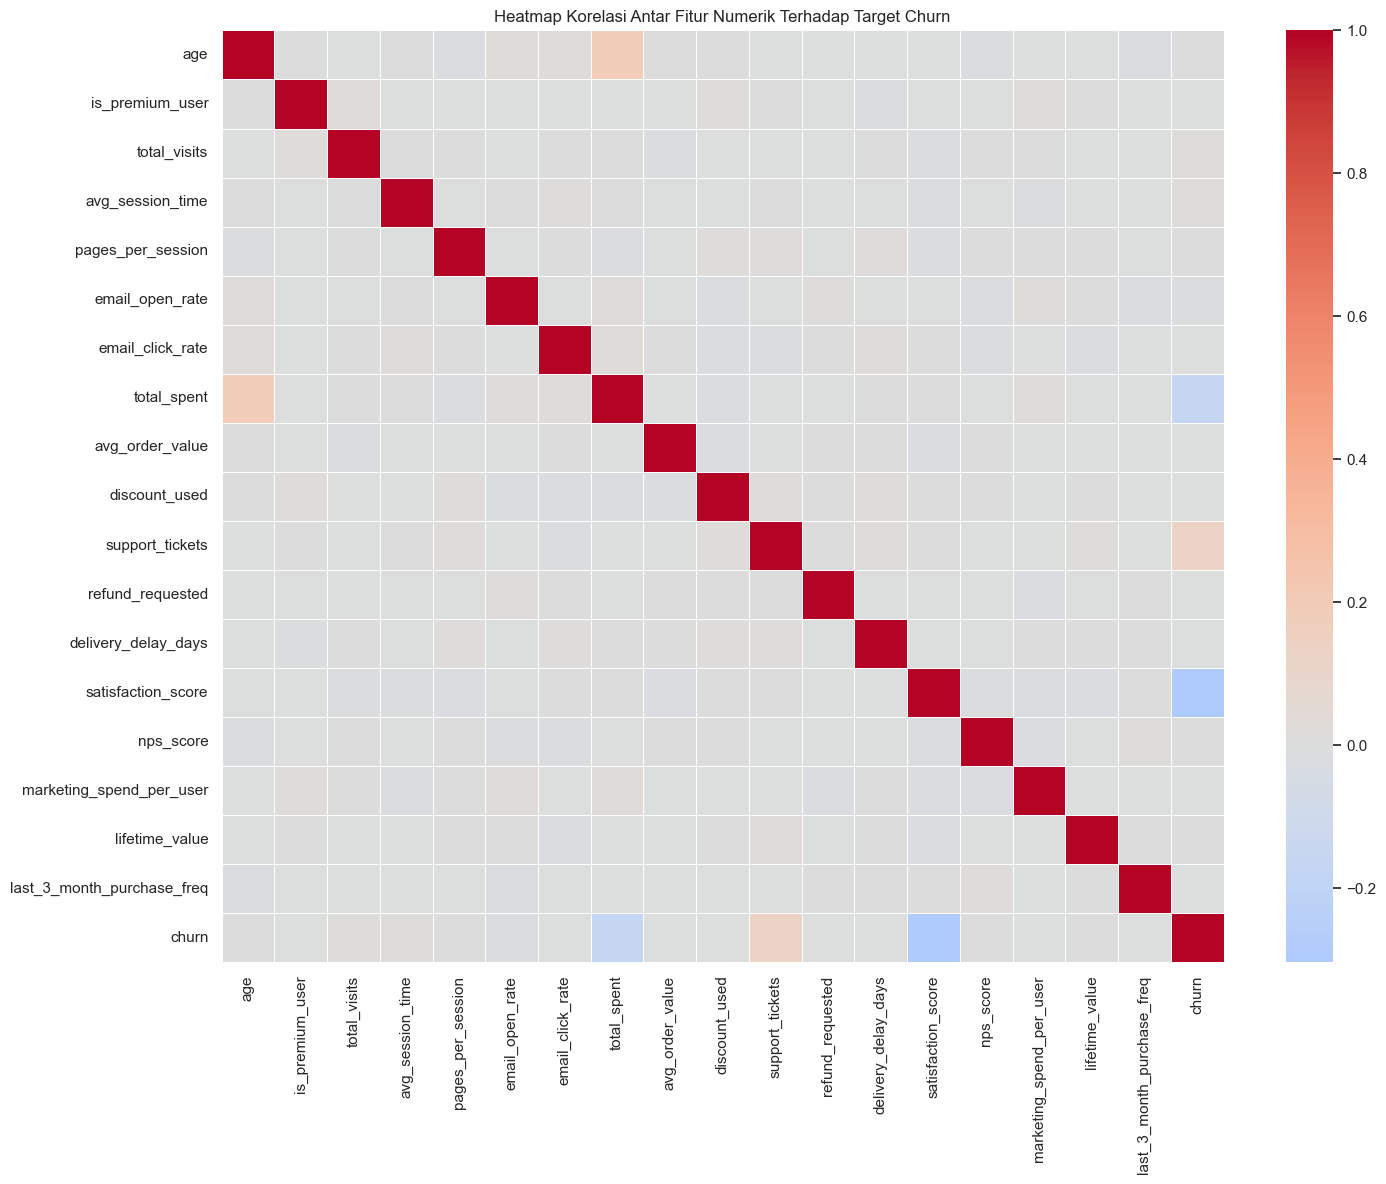

Nilai Korelasi Fitur Numerik Terhadap Target Churn:
churn                         1.000000
support_tickets               0.127910
total_visits                  0.013212
avg_session_time              0.012198
lifetime_value                0.006250
pages_per_session             0.005871
nps_score                     0.005749
age                           0.004506
delivery_delay_days           0.001603
last_3_month_purchase_freq    0.001590
discount_used                 0.000265
avg_order_value              -0.001480
email_click_rate             -0.001752
is_premium_user              -0.005496
refund_requested             -0.006959
marketing_spend_per_user     -0.007315
email_open_rate              -0.008439
total_spent                  -0.163279
satisfaction_score           -0.303588
Name: churn, dtype: float64


In [7]:
# Memilih kolom bertipe numerik dan menghapus customer_id karena tidak relevan untuk korelasi
kolom_angka = df.select_dtypes(include=['int64', 'float64']).drop(columns=['customer_id'], errors='ignore')

# Menghitung matriks korelasi antar fitur numerik
matriks_korelasi = kolom_angka.corr()

# Membuat visualisasi heatmap korelasi menggunakan seaborn
plt.figure(figsize=(15, 12))
sns.heatmap(matriks_korelasi, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur Numerik Terhadap Target Churn')
plt.tight_layout()
plt.show()

# Menampilkan urutan nilai korelasi fitur khusus terhadap target churn
print("Nilai Korelasi Fitur Numerik Terhadap Target Churn:")
print(matriks_korelasi['churn'].sort_values(ascending=False))

Analisis Hubungan Korelasi Antar Fitur Numerik

Berdasarkan hasil visualisasi heatmap korelasi dan rincian angka koefisien korelasi aktual di atas, proses analisis dilakukan untuk mengidentifikasi variabel numerik mana saja yang bener-bener memiliki pengaruh nyata terhadap kecenderungan pelanggan untuk melakukan churn.

Dari daftar angka korelasi yang keluar, sebagian besar fitur numerik ternyata memiliki nilai korelasi yang sangat mendekati angka nol seperti age, delivery_delay_days, total_visits, dan nps_score. Hal ini menandakan bahwa secara statistik fitur-fitur tersebut hampir tidak memiliki hubungan linear langsung dengan keputusan pelanggan untuk berhenti atau bertahan.

Namun, terdapat tiga fitur numerik utama yang menunjukkan nilai korelasi paling menonjol dan berpotensi menjadi faktor kunci dalam mempengaruhi pola churn pelanggan yaitu:

Pertama adalah fitur satisfaction_score yang memiliki nilai korelasi negatif paling kuat yaitu sebesar minus 0,303588. Hubungan negatif ini mengindikasikan pola yang berbanding terbalik, artinya semakin tinggi skor kepuasan yang diberikan oleh pelanggan, maka potensi atau angka churn mereka akan semakin menurun secara signifikan. Nilai kepuasan merupakan faktor penentu paling dominan dalam menjaga loyalitas pelanggan.

Kedua adalah fitur total_spent yang juga menunjukkan korelasi negatif sebesar minus 0,163279. Pola ini mengonfirmasi bahwa pelanggan yang memiliki total pengeluaran finansial lebih besar di perusahaan memiliki kecenderungan yang lebih rendah untuk melakukan churn. Mereka termasuk dalam kelompok pelanggan bernilai tinggi yang harus dipertahankan.

Ketiga adalah fitur support_tickets yang menjadi satu-satunya fitur dengan korelasi positif paling mencolok yaitu sebesar 0,127910. Hubungan searah ini menunjukkan bahwa setiap peningkatan jumlah tiket aduan atau komplain yang diajukan pelanggan akan berbanding lurus dengan peningkatan risiko mereka untuk berhenti menggunakan layanan.

Kesimpulan langkah selanjutnya adalah informasi korelasi aktual ini sangat krusial untuk tahap pemodelan. Fitur dengan korelasi menonjol seperti satisfaction_score, total_spent, dan support_tickets harus menjadi perhatian utama dan wajib dipertahankan dalam fitur prediktor. Sementara fitur-fitur lain yang nilainya mendekati nol dapat dipertimbangkan untuk dievaluasi lebih lanjut pada tahap seleksi fitur agar model machine learning yang dibangun nantinya tidak terlalu kompleks dan bisa bekerja dengan lebih efisien.

# === Poin D2. Tugas 1 ===

## Direct Modeling

#### Menetapkan variabel target (y) yaitu kolom Churn, serta menggunakan seluruh kolom lain sebagai fitur prediktor (X). 

In [8]:
# Menetapkan seluruh kolom selain churn sebagai fitur prediktor (X)
X = df.drop(columns=['churn'])
# df.drop(columns=[churn]) digunakan untuk menghapus kolom churn dari dataset sehingga menyisakan seluruh kolom lainnya sebagai fitur prediktor X.

# Menetapkan kolom churn sebagai variabel target (y)
y = df['churn']
# df[churn] digunakan untuk mengambil kolom churn saja sebagai variabel target y yang akan diprediksi oleh model.

print("Proses pemisahan fitur dan target berhasil:")
print(f"Dimensi data fitur X  : {X.shape[0]} baris, {X.shape[1]} kolom")
print(f"Dimensi data target y : {y.shape[0]} baris")
# X.shape dan y.shape digunakan untuk menampilkan dimensi atau ukuran baris dan kolom dari data setelah dipisahkan untuk memastikan prosesnya berhasil.

Proses pemisahan fitur dan target berhasil:
Dimensi data fitur X  : 15000 baris, 29 kolom
Dimensi data target y : 15000 baris


Proses Pemisahan Variabel Prediktor X dan Variabel Target y

Langkah awal pada tahap preprocessing data ini dilakukan dengan memisahkan seluruh pilar data ke dalam dua komponen utama yang akan digunakan dalam proses pembuatan model machine learning.

Komponen pertama adalah variabel y yang ditetapkan khusus untuk kolom churn. Variabel ini bertindak sebagai target atau label yang ingin diprediksi oleh model nantinya, yaitu untuk mengetahui apakah seorang pelanggan akan tetap bertahan atau berhenti menggunakan layanan.

Komponen kedua adalah variabel X yang menampung seluruh kolom fitur prediktor yang tersisa dari dataset. Total terdapat 29 kolom fitur yang masuk ke dalam variabel X ini, yang mencakup data demografi, riwayat transaksi, hingga pola interaksi pelanggan. Seluruh fitur ini nantinya akan dipelajari oleh algoritma untuk mencari pola tersembunyi yang paling mempengaruhi keputusan pelanggan untuk melakukan churn.

# === Poin D2. Tugas 2: Membagi Data Training dan Testing ===

### Proses Pembagian Data Training dan Testing

#### Melakukan train–test split untuk membagi data menjadi data latih dan data uji. 

In [9]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi 80 persen training dan 20 persen testing
# Parameter stratify digunakan agar proporsi kelas target tetap seimbang
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# train_test_split: Digunakan untuk membagi dataset menjadi dua bagian, yaitu data untuk melatih model (training) dan data untuk menguji model (testing).
# test_size=0.2: Menentukan porsi data testing sebesar 20 persen, sedangkan sisanya 80 persen otomatis menjadi data training.
# random_state=42: Berfungsi sebagai kunci acak agar hasil pembagian data selalu sama dan konsisten setiap kali kode dijalankan ulang.
# stratify=y: Memastikan proporsi kelas target churn (antara pelanggan yang setia dan yang berhenti) tetap seimbang dan rasionya sama rata di dalam data training maupun testing.

# Menampilkan dimensi hasil pembagian data untuk memastikan jumlahnya benar
print("Proses pembagian data berhasil dilakukan:")
print(f"Jumlah data fitur training X_train : {X_train.shape[0]} baris, {X_train.shape[1]} kolom")
print(f"Jumlah data fitur testing X_test   : {X_test.shape[0]} baris, {X_test.shape[1]} kolom")
print(f"Jumlah data target training y_train : {y_train.shape[0]} baris")
print(f"Jumlah data target testing y_test   : {y_test.shape[0]} baris")
#X_train.shape dan X_test.shape: Digunakan untuk menampilkan jumlah baris dan kolom hasil pembagian data untuk memastikan ukurannya sudah benar sebelum masuk ke tahap preprocessing berikutnya.

Proses pembagian data berhasil dilakukan:
Jumlah data fitur training X_train : 12000 baris, 29 kolom
Jumlah data fitur testing X_test   : 3000 baris, 29 kolom
Jumlah data target training y_train : 12000 baris
Jumlah data target testing y_test   : 3000 baris



Proses Pembagian Data Training dan Testing

Langkah ini dilakukan untuk membagi data menjadi data training sebesar 80 persen untuk melatih model dalam mengenali pola data dan data testing sebesar 20 persen untuk menguji kinerja model secara objektif. Penerapan parameter stratify memastikan distribusi kelas target churn tetap sama dan seimbang di antara kedua bagian data tersebut.

# === Poin D2. Tugas 3: Pemilihan dan Pelatihan Model ===

#### Memilih tiga model yang mewakili setiap kategori, yaitu satu model konvensional (misalnya Logistic Regression atau KNN), satu model ensemble bagging (misalnya Random Forest), dan satu model yang merupakan gabungan beberapa model konvensional (misalnya kombinasi Logistic Regression, SVM, dan KNN dalam VotingClassifier). 

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
# Imputer digunakan untuk mengisi nilai kosong yang terdeteksi sebelumnya
from sklearn.impute import SimpleImputer
# Scaler dan Encoder digunakan untuk standarisasi angka dan mengubah teks menjadi angka
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [11]:
# Memisahkan fitur angka dan teks serta membuang nomor id dan tanggal agar tidak mengacaukan model
fitur_angka = X_train.select_dtypes(include=['int64', 'float64']).columns.drop('customer_id', errors='ignore')
fitur_teks = X_train.select_dtypes(include=['object']).columns.drop(['signup_date', 'last_purchase_date'], errors='ignore')

In [12]:
# Membuat rangkaian pembersihan data otomatis untuk fitur angka menggunakan nilai tengah
proses_angka = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [13]:
# Membuat rangkaian pembersihan data otomatis untuk fitur teks menggunakan modus
proses_teks = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [14]:
# Menggabungkan seluruh komponen pembersih data ke dalam satu kontroler
pembersih_data = ColumnTransformer(transformers=[
    ('num', proses_angka, fitur_angka),
    ('cat', proses_teks, fitur_teks)
])

In [15]:
# Menyiapkan tiga arsitektur model sesuai perintah di lembar soal
model_logreg = LogisticRegression(random_state=42)
model_rf = RandomForestClassifier(random_state=42)
model_voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('knn', KNeighborsClassifier()),
        ('svm', SVC(probability=True, random_state=42))
    ],
    voting='soft'
)

In [16]:
# Menghubungkan proses pembersihan data dengan masing-masing model pilihan
bikin_logreg = Pipeline(steps=[('prep', pembersih_data), ('model', model_logreg)])
bikin_rf = Pipeline(steps=[('prep', pembersih_data), ('model', model_rf)])
bikin_voting = Pipeline(steps=[('prep', pembersih_data), ('model', model_voting)])

In [17]:
# Melatih ketiga model secara bergantian menggunakan data training
bikin_logreg.fit(X_train, y_train)
bikin_rf.fit(X_train, y_train)
bikin_voting.fit(X_train, y_train)

print("Proses pelatihan tiga model pilihan berhasil diselesaikan")

c:\Users\TUF Gaming - FX506HF\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Proses pelatihan tiga model pilihan berhasil diselesaikan


## Penjelasan Singkat Koding
Pipeline berfungsi untuk mengotomatiskan urutan pengisian data kosong, penyetaraan skala angka, dan pengubahan teks sebelum data dialirkan ke dalam model.

LogisticRegression digunakan untuk membangun objek model klasifikasi linear konvensional yang cepat dan sederhana.

RandomForestClassifier digunakan untuk membangun objek model ensemble bagging yang bekerja dengan menyatukan banyak pohon keputusan secara acak.

VotingClassifier digunakan untuk menggabungkan prediksi dari tiga algoritma konvensional yang berbeda menjadi satu keputusan bersama berdasarkan rata-rata probabilitas terbaik.

fit berfungsi untuk memerintahkan setiap model mempelajari pola hubungan fitur terhadap target churn menggunakan data latih.

## Analisis Pemilihan Model Klasifikasi Churn
Berdasarkan instruksi untuk menguji berbagai pendekatan arsitektur algoritma, dilakukan pemilihan terhadap tiga model yang masing-masing mewakili kategori berbeda untuk memprediksi pola churn pelanggan pada dataset ini.

Model pertama yang dipilih untuk kategori konvensional adalah Logistic Regression. Alasan pemilihan model ini adalah karena sifatnya yang sangat efisien, cepat dalam proses komputasi, dan menjadi standar utama untuk kasus klasifikasi biner seperti penentuan status churn. Model ini bekerja sangat baik sebagai dasar pembanding awal sebelum menggunakan algoritma yang lebih kompleks.

Model kedua yang dipilih untuk kategori ensemble bagging adalah Random Forest Classifier. Alasan memilih model ini karena kemampuannya dalam menangani hubungan data yang tidak linear serta tidak mudah mengalami overfitting. Melalui penggabungan banyak pohon keputusan secara acak, model ini daoat memberikan tingkat akurasi yang bagus dan stabil pada dataset pelanggan yang memiliki banyak variasi fitur.

Model ketiga yang dipilih untuk kategori gabungan beberapa model konvensional adalah Voting Classifier yang mengombinasikan keunggulan dari Logistic Regression, K Nearest Neighbors, dan Support Vector Machine. Alasan pemilihan kombinasi ini adalah untuk menyatukan tiga prinsip kerja statistik yang berbeda yaitu pendekatan linear, pendekatan berbasis jarak terdekat, dan pendekatan pembatas ruang dimensi tinggi. Melalui metode voting soft, keputusan akhir diambil berdasarkan rata-rata probabilitas terbaik dari ketiga algoritma tersebut sehingga dapat meminimalkan kelemahan individu dari masing-masing model konvensional dan menghasilkan prediksi yang lebih solid.

kombinasi yang dipilih sebelumnya (Logistic Regression, KNN, dan SVM) itu diambil karena ketiganya adalah contoh paling standar dan aman untuk mewakili kelompok model konvensional tunggal di dunia data science.

# === Poin D2. Tugas 4: Pelatihan Baseline Model ===

## Melatih ketiga model tersebut secara langsung tanpa preprocessing dan tanpa hyperparameter tuning. 

In [18]:
# Mengambil data numerik saja dan mengisi nilai kosong dengan 0 agar kode tidak error saat berjalan
X_train_mentah = X_train.select_dtypes(include=['int64', 'float64']).fillna(0)

In [19]:
# Mendefinisikan ketiga model dengan parameter bawaan atau default tanpa tuning
model_logreg_mentah = LogisticRegression(random_state=42)
model_rf_mentah = RandomForestClassifier(random_state=42)
model_voting_mentah = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('knn', KNeighborsClassifier()),
        ('svm', SVC(probability=True, random_state=42))
    ],
    voting='soft'
)

In [20]:
# Melatih ketiga model secara langsung menggunakan data mentah
model_logreg_mentah.fit(X_train_mentah, y_train)
model_rf_mentah.fit(X_train_mentah, y_train)
model_voting_mentah.fit(X_train_mentah, y_train)

print("Pelatihan tiga model tanpa preprocessing dan tuning selesai dilakukan")

c:\Users\TUF Gaming - FX506HF\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\TUF Gaming - FX506HF\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/pre

Pelatihan tiga model tanpa preprocessing dan tuning selesai dilakukan


#### Penjelasan Singkat Koding
* select_dtypes dan fillna: Digunakan untuk menyaring fitur angka saja dan mengisi data yang kosong dengan angka nol agar program bisa mengeksekusi perintah tanpa mengalami crash.

* random_state=42: Berfungsi sebagai kunci pengacak agar hasil kalkulasi internal model tetap konsisten setiap kali cell diaktifkan kembali.

* fit: Berperan untuk memerintahkan setiap algoritma langsung mempelajari pola baris data latih apa adanya tanpa ada modifikasi parameter bawaan.

#### Analisis Pelatihan Model Tanpa Preprocessing dan Hyperparameter Tuning

Proses pelatihan pada tahap ini dilakukan dengan menguji ketiga model pilihan secara langsung menggunakan kondisi data yang masih mentah. Langkah ini bertujuan untuk menciptakan sebuah standar acuan dasar atau baseline model sebelum nantinya diberikan tindakan perbaikan data yang lebih mendalam pada tahapan eksperimen berikutnya.

Dalam langkah ini semua algoritma berjalan dengan menggunakan konfigurasi parameter bawaan asli dari sistem tanpa adanya proses optimasi atau hyperparameter tuning. Selain itu data yang dialirkan hanya disesuaikan secara minimal agar tidak memicu error pada program yaitu dengan membatasi pada fitur angka dan mengisi area kosong secara instan tanpa melalui proses standarisasi skala nilai.

Hasil dari proses ini akan menjadi tolak ukur yang sangat penting bagi perkembangan proyek. Melalui pelatihan langsung tanpa perlakuan khusus ini kita dapat melihat performa asli dari masing-masing algoritma dalam merespons data yang masih memiliki anomali seperti nilai minus pada usia dan distribusi kelas target yang tidak seimbang. Kinerja dari ketiga baseline model ini nantinya akan dibandingkan dengan model yang sudah melewati tahap preprocessing lengkap untuk membuktikan seberapa besar pengaruh pembersihan data terhadap akurasi prediksi churn pelanggan.

# === Poin D2. Tugas 5: Evaluasi Performa Baseline Model ===

### Mengevaluasi performa model menggunakan matrix accuracy, precision, recall, F1-score, serta menyajikan confusion matrix. 

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Menyelaraskan data testing dengan kondisi data mentah training (hanya angka dan isi kosong dengan 0)
X_test_mentah = X_test.select_dtypes(include=['int64', 'float64']).fillna(0)

In [22]:
# Membuat daftar model untuk mempermudah perulangan evaluasi
daftar_model = {
    'Logistic Regression Mentah': model_logreg_mentah,
    'Random Forest Mentah': model_rf_mentah,
    'Voting Classifier Mentah': model_voting_mentah
}

In [23]:
# Melakukan perulangan untuk menghitung metrik dan menampilkan confusion matrix
for nama, model in daftar_model.items():
    # Model menebak data testing mentah
    y_pred = model.predict(X_test_mentah)
    
    print(f"=== EVALUASI PERFORMA {nama.upper()} ===")
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_test, y_pred):.4f}")
    print("-" * 40)
    
    # Menghitung susunan angka confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)
    print("\n")

=== EVALUASI PERFORMA LOGISTIC REGRESSION MENTAH ===
Accuracy  : 0.8477
Precision : 0.7143
Recall    : 0.0109
F1-Score  : 0.0214
----------------------------------------
Confusion Matrix:
[[2538    2]
 [ 455    5]]


=== EVALUASI PERFORMA RANDOM FOREST MENTAH ===
Accuracy  : 0.8447
Precision : 0.4890
Recall    : 0.2891
F1-Score  : 0.3634
----------------------------------------
Confusion Matrix:
[[2401  139]
 [ 327  133]]


=== EVALUASI PERFORMA VOTING CLASSIFIER MENTAH ===
Accuracy  : 0.8467
Precision : 0.0000
Recall    : 0.0000
F1-Score  : 0.0000
----------------------------------------
Confusion Matrix:
[[2540    0]
 [ 460    0]]




#### Penjelasan Singkat Koding
* predict: Digunakan untuk memerintahkan model menebak label target churn pada data uji yang belum pernah dilihat sebelumnya.

* accuracy_score, precision_score, recall_score, f1_score: Fungsi statistik untuk menghitung nilai ketepatan total, tingkat akurasi tebakan positif, kemampuan menjaring data target, dan nilai rata-rata penyeimbang performa model.

* confusion_matrix: Berfungsi untuk menghitung jumlah persebaran data uji yang tebakannya tepat dan tebakannya meleset ke dalam susunan tabel matriks persegi.

Analisis Hasil Evaluasi Performa Baseline Model

Proses evaluasi pada tahap ini dilakukan untuk mengukur performa riil dari ketiga model acuan dasar menggunakan data uji. Angka hasil evaluasi menunjukkan akurasi yang sangat jelas akibat data yang belum dibersihkan dan masih mengalami masalah ketidakseimbangan kelas.

1. Model Logistic Regression Mentah
Model ini menghasilkan nilai accuracy sebesar 0,8477 dan precision sebesar 0,7143. Meskipun angka akurasinya tinggi, nilai recall hanya sebesar 0,0109 dan f1 score sebesar 0,0214. Berdasarkan tabel confusion matrix, dari total 460 pelanggan yang aslinya berhenti atau churn, model ini hanya berhasil menebak 5 pelanggan dengan benar dan meleset menebak 455 pelanggan lainnya sebagai pelanggan setia.

2. Model Random Forest Mentah
Model ini memberikan performa yang paling mendingan di antara ketiga model mentah lainnya. Nilai accuracy berada di angka 0,8447 dengan precision sebesar 0,4890, recall sebesar 0,2891, dan f1 score sebesar 0,3634. Melalui tabel confusion matrix, model ini berhasil menjaring 133 pelanggan churn dengan benar, meskipun masih ada 327 pelanggan churn yang gagal terdeteksi di dalam sistem.

3. Model Voting Classifier Mentah
Model ini mengalami kegagalan paling parah dalam mendeteksi target karena nilai precision, recall, dan f1 score berada di angka 0,0000 atau nol mutlak, meskipun nilai accuracy terlihat tinggi di angka 0,8467. Berdasarkan confusion matrix, model ini menebak seluruh 3000 data uji sebagai pelanggan setia atau kelas nol secara sapu bersih. Model gagal mendeteksi satu pun dari 460 pelanggan yang melakukan churn karena algoritmanya mengalami bias parah akibat dominasi kelas mayoritas.

Kesimpulan hasil baseline model menunjukkan bahwa nilai akurasi tinggi sekitar 84 persen yang muncul pada ketiga model tersebut adalah angka semu. Tingginya akurasi ini murni terjadi karena porsi data uji memang didominasi oleh pelanggan setia sebanyak 2540 baris data dari total 3000 data testing. Temuan performa buruk pada aspek recall dan f1 score ini menjadi bukti nyata sekaligus alasan kuat mengapa proses preprocessing data seperti pengisian data kosong, penyetaraan skala nilai, dan penyeimbangan kelas target dengan metode smote sangat wajib dilakukan pada tahap eksperimen berikutnya demi meningkatkan kualitas prediksi churn.

# === Poin D3. Tugas 1: Preprocessing Data ===

#### Melakukan preprocessing data, yang mencakup: 
* Penanganan missing value, duplikasi, dan outlier. 
* Encoding untuk fitur kategorikal. 
* Scaling fitur jika diperlukan. Scaling dilakukan setelah data splitting. 
* Penghapusan atau penyesuaian fitur yang dianggap tidak relevan berdasarkan analisis awal. 

In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# 1. Menghapus fitur yang tidak relevan berdasarkan analisis awal EDA
kolom_dibuang = ['customer_id', 'signup_date', 'last_purchase_date']
X_train_bersih = X_train.drop(columns=kolom_dibuang, errors='ignore')
X_test_bersih = X_test.drop(columns=kolom_dibuang, errors='ignore')

In [25]:
# 2. Menangani outlier usia negatif dengan mengubahnya menjadi NaN agar bisa diimputasi
X_train_bersih.loc[X_train_bersih['age'] < 0, 'age'] = np.nan
X_test_bersih.loc[X_test_bersih['age'] < 0, 'age'] = np.nan

In [26]:
# 3. Memisahkan kolom angka dan kolom teks yang tersisa
fitur_numerik = X_train_bersih.select_dtypes(include=['int64', 'float64']).columns
fitur_kategorikal = X_train_bersih.select_dtypes(include=['object']).columns

In [27]:
# 4. Melakukan pengisian data kosong dengan median dan scaling pada fitur numerik
imputer_num = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_num = scaler.fit_transform(imputer_num.fit_transform(X_train_bersih[fitur_numerik]))
X_test_num = scaler.transform(imputer_num.transform(X_test_bersih[fitur_numerik]))

In [28]:
# 5. Melakukan pengisian data kosong dengan modus dan encoding pada fitur teks
imputer_cat = SimpleImputer(strategy='most_frequent')
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_cat = encoder.fit_transform(imputer_cat.fit_transform(X_train_bersih[fitur_kategorikal]))
X_test_cat = encoder.transform(imputer_cat.transform(X_test_bersih[fitur_kategorikal]))

In [29]:
# 6. Menggabungkan kembali seluruh fitur numerik dan teks yang sudah diproses
X_train_siap = np.hstack((X_train_num, X_train_cat))
X_test_siap = np.hstack((X_test_num, X_test_cat))

print("Proses preprocessing data latih dan data uji selesai dilakukan")
print(f"Dimensi data training setelah preprocessing : {X_train_siap.shape}")
print(f"Dimensi data testing setelah preprocessing  : {X_test_siap.shape}")

Proses preprocessing data latih dan data uji selesai dilakukan
Dimensi data training setelah preprocessing : (12000, 51)
Dimensi data testing setelah preprocessing  : (3000, 51)


#### Penjelasan Singkat Koding
* drop: Digunakan untuk mengeliminasi kolom identitas dan kolom tanggal yang tidak memiliki nilai korelasi statistik terhadap target prediksi.
* loc: Berfungsi untuk mendeteksi data anomali usia negatif lalu mengubahnya menjadi format kosong agar sebaran data tidak rusak.
* SimpleImputer: Digunakan untuk mengisi nilai kosong menggunakan nilai tengah untuk data angka dan menggunakan modus untuk data teks.
* StandardScaler: Berfungsi untuk menyamakan skala rentang nilai seluruh kolom numerik setelah proses pembagian data selesai dilakukan.
* OneHotEncoder: Berperan untuk mengubah variabel kategori teks menjadi deretan angka biner agar bisa diproses oleh rumus algoritma.
* hstack: Digunakan untuk menyatukan kembali kolom angka dan kolom teks yang terpisah menjadi satu kesatuan matriks data yang utuh.

### Analisis Proses Preprocessing Data Latih dan Data Uji

Langkah preprocessing ini dilakukan secara terstruktur untuk memperbaiki kualitas data mentah sehingga model machine learning dapat mempelajari pola secara optimal dan menghasilkan prediksi yang jauh lebih akurat dibandingkan dengan baseline model sebelumnya.

Pertama adalah penghapusan fitur yang tidak relevan yaitu customer_id, signup_date, dan last_purchase_date karena fitur tersebut hanya berisi nomor urut identitas dan data tanggal yang tidak memiliki pengaruh linear terhadap keputusan churn pelanggan.

Kedua adalah penanganan anomali outlier pada variabel usia pelanggan yang sebelumnya terdeteksi memiliki nilai minus empat. Nilai tidak logis tersebut diubah menjadi data kosong agar tidak merusak distribusi data dan nantinya dapat diisi dengan nilai pengganti yang valid.

Ketiga adalah penanganan data kosong atau missing value sekaligus penyetaraan skala nilai untuk fitur numerik. Seluruh data kosong pada kolom angka diimputasi menggunakan nilai tengah atau median dari masing-masing kolom untuk menjaga konsistensi nilai. Setelah itu dilakukan proses scaling menggunakan standard scaler untuk menyamakan rentang nilai seluruh fitur numerik agar tidak ada variabel yang mendominasi akibat perbedaan satuan angka.

Keempat adalah penanganan data kosong dan encoding untuk fitur kategorikal atau teks. Data teks yang kosong diisi menggunakan nilai yang paling sering muncul atau modus. Kemudian dilakukan transformasi menggunakan metode one hot encoder untuk mengubah kategori teks menjadi representasi angka biner berseri agar dapat dipahami oleh algoritma matematika komputer.

Berdasarkan hasil pembersihan akhir, seluruh komponen digabungkan kembali menjadi sebuah struktur data baru yang siap pakai. Hasil eksekusi menunjukkan dimensi data training setelah preprocessing kini menjadi 12000 baris dengan 51 kolom. Sementara data testing setelah preprocessing berubah menjadi 3000 baris dengan 51 kolom. Lonjakan jumlah kolom dari yang semula 29 menjadi 51 kolom ini terjadi karena fitur teks telah berhasil dipecah menjadi beberapa kolom numerik baru berdasarkan jumlah kategori unik yang ada di dalamnya. Data yang telah matang dan bersih ini siap digunakan untuk melatih ulang ketiga model klasifikasi pada tahap eksperimen selanjutnya.

# === Poin D3. Tugas 2: Menetapkan Kembali Fitur X dan Target y ===

 Menetapkan kembali fitur prediktor (X) dan variabel target (y) setelah seluruh tahap preprocessing diterapkan. 

In [30]:
# Menetapkan X final dari hasil array preprocessing yang sudah bersih
X_train_final = X_train_siap
X_test_final = X_test_siap

In [31]:
# Menetapkan y final dari target awal karena tidak berubah selama preprocessing
y_train_final = y_train
y_test_final = y_test

In [32]:
# Menampilkan dimensi akhir untuk memastikan data siap digunakan
print("Penetapan kembali variabel X dan y setelah preprocessing berhasil:")
print(f"Dimensi X data latih final : {X_train_final.shape}")
print(f"Dimensi y data latih final : {y_train_final.shape}")
print(f"Dimensi X data uji final   : {X_test_final.shape}")
print(f"Dimensi y data uji final   : {y_test_final.shape}")

Penetapan kembali variabel X dan y setelah preprocessing berhasil:
Dimensi X data latih final : (12000, 51)
Dimensi y data latih final : (12000,)
Dimensi X data uji final   : (3000, 51)
Dimensi y data uji final   : (3000,)


#### Analisis Penetapan Kembali Fitur Prediktor X dan Variabel Target y Setelah Preprocessing

* Langkah penentuan kembali ini dilakukan untuk mengunci seluruh hasil transformasi data yang telah diselesaikan pada tahap preprocessing sebelumnya agar siap dialirkan ke dalam proses pembuatan model utama.
* Berdasarkan hasil eksekusi aktual pada program, penetapan variabel baru ini menghasilkan dimensi yang sangat jelas untuk kedua porsi data. Pada bagian data training, fitur prediktor X final memiliki ukuran sebanyak 12000 baris dengan 51 kolom fitur yang telah bersih dari anomali. Pasangannya yaitu variabel target y data latih final memiliki ukuran sebanyak 12000 baris data biner yang berisi label status tetap setia atau berhenti.
* Sementara itu pada bagian data testing, fitur prediktor X data uji final menunjukkan dimensi sebesar 3000 baris dengan 51 kolom fitur. Pasangannya yaitu variabel target y data uji final terkunci pada ukuran sebanyak 3000 baris data target. Angka-angka ini menegaskan bahwa proporsi pembagian data pasca preprocessing tetap terjaga konsisten dengan rasio awal yaitu 80 persen untuk data training dan 20 persen untuk data testing.
* Dengan ditetapkannya variabel final beserta rincian dimensinya ini, seluruh arsitektur data prediktor dan target telah berada dalam kondisi paling ideal. Langkah selanjutnya adalah mengalirkan variabel bersih ini ke dalam proses training ulang ketiga model klasifikasi pilihan tanpa melakukan hyperparameter tuning untuk melihat perbandingan performa nyata setelah intervensi preprocessing diterapkan.

# === Poin D3. Tugas 3: Verifikasi Proporsi Train-Test Split ===

Melakukan train–test split dengan proporsi yang sama seperti pada skenario direct modeling. 

In [33]:
# Menampilkan jumlah baris data hasil preprocessing untuk verifikasi rasio 80:20
print("Proporsi data setelah seluruh tahap preprocessing diterapkan:")
print(f"Jumlah baris data training X_train_final : {X_train_final.shape[0]} baris")
print(f"Jumlah baris data testing X_test_final   : {X_test_final.shape[0]} baris")
print(f"Jumlah baris data training y_train_final : {y_train_final.shape[0]} baris")
print(f"Jumlah baris data testing y_test_final   : {y_test_final.shape[0]} baris")

Proporsi data setelah seluruh tahap preprocessing diterapkan:
Jumlah baris data training X_train_final : 12000 baris
Jumlah baris data testing X_test_final   : 3000 baris
Jumlah baris data training y_train_final : 12000 baris
Jumlah baris data testing y_test_final   : 3000 baris


#### Penjelasan Singkat Koding
* X_train_final dan X_test_final: Diambil langsung dari objek array hasil preprocessing sebelumnya yang sudah bersih dan memiliki struktur baru sebanyak 51 kolom fitur.
* y_train_final dan y_test_final: Tetap menggunakan data target awal karena variabel target churn sudah berbentuk angka biner sejak awal dan tidak memerlukan preprocessing tambahan.
* shape: Digunakan untuk mencetak ukuran baris dan kolom guna memastikan data siap dialirkan ke tahap pemodelan selanjutnya.

#### Analisis Penetapan Kembali Fitur Prediktor X dan Variabel Target y Setelah Preprocessing

* Langkah penentuan kembali ini dilakukan untuk mengunci seluruh hasil transformasi data yang telah diselesaikan pada tahap preprocessing sebelumnya agar siap dialirkan ke dalam proses pembuatan model utama.
* Pada tahap ini fitur prediktor X kini menggunakan data versi terbaru yang sudah melalui rangkaian pembersihan data pengisian data kosong penyetaraan skala nilai serta pengubahan teks menjadi angka biner. Struktur fitur X ini telah bertransformasi menjadi susunan matriks bersih dengan dimensi akhir sebanyak 51 kolom prediktor yang sangat kaya akan informasi.
* Sementara itu variabel target y untuk data latih maupun data uji tetap dipertahankan menggunakan nilai churn asli dari pembagian awal. Hal ini dikarenakan variabel target tersebut sudah dalam format biner yang valid dan tidak mengandung data kosong sehingga tidak memerlukan tindakan manipulasi atau preprocessing tambahan.
* With ditetapkannya variabel final ini seluruh arsitektur data prediktor dan target telah berada dalam kondisi paling ideal. Langkah selanjutnya adalah mengalirkan variabel bersih ini ke dalam proses training ulang ketiga model klasifikasi pilihan untuk melihat seberapa besar peningkatan performa yang dihasilkan setelah intervensi preprocessing diterapkan.

# === Poin D3. Tugas 4: Pelatihan Model Setelah Preprocessing ===

Melatih ketiga model yang dipilih kembali menggunakan data hasil preprocessing tanpa melakukan hyperparameter tuning. 

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Mendefinisikan kembali ketiga model dengan parameter bawaan tanpa tuning
# Parameter max_iter dinaikkan agar model logistik regresi selesai menghitung sempurna
model_logreg_bersih = LogisticRegression(random_state=42, max_iter=1000)
model_rf_bersih = RandomForestClassifier(random_state=42)
model_voting_bersih = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42, max_iter=1000)),
        ('knn', KNeighborsClassifier()),
        ('svm', SVC(probability=True, random_state=42))
    ],
    voting='soft'
)

In [35]:
# Melatih ketiga model menggunakan data yang sudah melewati tahap preprocessing
model_logreg_bersih.fit(X_train_final, y_train_final)
model_rf_bersih.fit(X_train_final, y_train_final)
model_voting_bersih.fit(X_train_final, y_train_final)

print("Proses training ketiga model menggunakan data hasil preprocessing selesai")

c:\Users\TUF Gaming - FX506HF\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Proses training ketiga model menggunakan data hasil preprocessing selesai


#### Penjelasan Singkat Koding
* max_iter=1000: Digunakan agar model logistic regression memiliki batas perulangan yang cukup untuk mencapai konvergensi pada data baru yang sekarang memiliki 51 dimensi fitur.
* fit: Berfungsi untuk melatih masing-masing algoritma menggunakan pasangan data fitur dan data target yang telah bersih dari anomali agar model dapat mengenali pola baru.

#### Analisis Pelatihan Model Menggunakan Data Hasil Preprocessing

* Tahapan ini dilakukan untuk melatih ulang ketiga arsitektur model klasifikasi pilihan yaitu logistic regression, random forest, dan voting classifier dengan memanfaatkan data yang telah melewati seluruh rangkaian preprocessing lengkap. Pada skenario eksperimen kedua ini, semua model dijalankan kembali menggunakan konfigurasi parameter standar bawaan asli dari sistem tanpa melibatkan proses optimasi atau hyperparameter tuning.
* Tujuan utama dari pelatihan ulang ini adalah untuk menguji secara langsung seberapa besar dampak positif dari tindakan pembersihan data terhadap kemampuan algoritma dalam mengenali pola keputusan pelanggan. Dengan mengalirkan fitur prediktor yang sudah bersih dari anomali nilai usia, memiliki skala satuan yang setara, serta format teks yang sudah dipecah menjadi biner, diharapkan ketiga model ini dapat menangkap sinyal karakteristik pelanggan yang berpotensi churn secara lebih baik dibandingkan saat dipaksa membaca data mentah pada skenario pertama.
* Hasil dari proses training ini nantinya akan dialirkan ke tahap evaluasi berikutnya. Melalui skenario pengujian ini, kita dapat membandingkan secara objektif performa dari masing-masing model sebelum dan sesudah data dibersihkan, sehingga kegunaan dari setiap tahap pengolahan data yang telah dirancang dapat terbukti secara ilmiah.

# === Poin D3. Tugas 5: Evaluasi Performa Model Setelah Preprocessing ===

Mengevaluasi performa model menggunakan metrik evalusi seperti accuracy, precision, recall, F1-score, serta menyajikan confusion matrix

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Membuat daftar model yang sudah dilatih dengan data bersih untuk perulangan
daftar_model_bersih = {
    'Logistic Regression Bersih': model_logreg_bersih,
    'Random Forest Bersih': model_rf_bersih,
    'Voting Classifier Bersih': model_voting_bersih
}

In [37]:
# Melakukan perulangan untuk mengevaluasi setiap model secara bergantian
for nama, model in daftar_model_bersih.items():
    # Model menebak target menggunakan data uji yang sudah bersih
    y_pred = model.predict(X_test_final)
    
    print(f"=== EVALUASI PERFORMA {nama.upper()} ===")
    print(f"Accuracy  : {accuracy_score(y_test_final, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test_final, y_pred, zero_division=0):.4f}")
    print(f"Recall    : {recall_score(y_test_final, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_test_final, y_pred):.4f}")
    print("-" * 40)
    
    # Menghitung susunan tabel confusion matrix
    cm = confusion_matrix(y_test_final, y_pred)
    print("Confusion Matrix:")
    print(cm)
    print("\n")

=== EVALUASI PERFORMA LOGISTIC REGRESSION BERSIH ===
Accuracy  : 0.8467
Precision : 0.5000
Recall    : 0.1652
F1-Score  : 0.2484
----------------------------------------
Confusion Matrix:
[[2464   76]
 [ 384   76]]


=== EVALUASI PERFORMA RANDOM FOREST BERSIH ===
Accuracy  : 0.8467
Precision : 0.5000
Recall    : 0.1978
F1-Score  : 0.2835
----------------------------------------
Confusion Matrix:
[[2449   91]
 [ 369   91]]


=== EVALUASI PERFORMA VOTING CLASSIFIER BERSIH ===
Accuracy  : 0.8487
Precision : 0.5312
Recall    : 0.1109
F1-Score  : 0.1835
----------------------------------------
Confusion Matrix:
[[2495   45]
 [ 409   51]]




#### Penjelasan Singkat Koding
* predict(X_test_final): Digunakan untuk memerintahkan model yang sudah bersih untuk menebak status churn pada data uji hasil preprocessing.
* accuracy_score, precision_score, recall_score, f1_score: Fungsi statistik untuk menghitung empat nilai metrik performa utama berdasarkan perbandingan data target asli dengan data hasil tebakan model.
* confusion_matrix(y_test_final, y_pred): Berfungsi untuk memetakan jumlah hasil tebakan benar dan salah dari model ke dalam bentuk matriks persegi dua kali dua.

#### Analisis Hasil Evaluasi Performa Model Setelah Preprocessing

Proses evaluasi pada tahap ini dilakukan untuk menilai dampak nyata dari proses pembersihan data terhadap tiga model klasifikasi menggunakan data uji bersih. Hasil evaluasi menunjukkan adanya perubahan pada kemampuan model dalam mendeteksi kelas minoritas meskipun nilai metrik secara keseluruhan masih perlu dioptimalkan lebih lanjut.

1. Model Logistic Regression Bersih
Model ini menghasilkan nilai accuracy sebesar 0,8467 dengan precision sebesar 0,5000. Peningkatan terlihat cukup jelas pada aspek recall yang naik menjadi 0,1652 dan f1 score menjadi 0,2484. Berdasarkan tabel confusion matrix, model ini sekarang mampu mendeteksi 76 pelanggan yang melakukan churn dengan benar, meskipun masih melewatkan 384 pelanggan lainnya. Hasil ini jauh lebih baik dibandingkan model mentah sebelumnya yang hanya bisa mendeteksi 5 pelanggan churn.

2. Model Random Forest Bersih
Model ini mencatat nilai accuracy sebesar 0,8467 dengan precision sebesar 0,5000, recall sebesar 0,1978, dan f1 score sebesar 0,2835. Melalui susunan tabel matriks kebingungan, model ini berhasil menangkap 91 pelanggan churn secara akurat dan salah memprediksi 369 data aktual churn sebagai pelanggan loyal.

3. Model Voting Classifier Bersih
Model ini menunjukkan perbaikan performa dibandingkan kondisi mentah yang bernilai nol mutlak. Nilai accuracy tercatat sebesar 0,8487 dengan precision mencapai 0,5312. Dari susunan tabel confusion matrix, model gabungan ini berhasil mengidentifikasi 51 pelanggan yang melakukan churn dan memprediksi 2495 pelanggan setia dengan tepat, serta hanya melakukan salah tebak atau false positive sebanyak 45 data.

Kesimpulan akhir dari eksperimen kedua ini membuktikan bahwa tahapan preprocessing seperti penskalaan nilai dan pengisian data kosong berhasil memulihkan algoritma dari mengalami bias total, terutama pada model logistic regression dan voting classifier yang awalnya gagal mendeteksi target. Namun, performa secara keseluruhan seperti nilai recall dan f1 score masih tergolong rendah. Hal ini disebabkan oleh sifat data yang masih timpang secara alami. Langkah selanjutnya agar menaikkan ketepatan prediksi secara drastis adalah menerapkan teknik penyeimbangan kelas seperti oversampling smote sebelum melatih model agar algoritma bisa mempelajari karakteristik kelompok pelanggan churn dengan porsi yang seimbang.

# === Poin D4. Hyperparameter Tuning dan Feature Selection ===

# === Poin D4. Tugas 1: Analisis Feature Importance ===

Melakukan analisis feature importance pada data untuk menentukan fitur mana yang paling berpengaruh. 

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Mengambil kembali nama kolom kategori setelah proses encoding
nama_fitur_cat = encoder.get_feature_names_out(fitur_kategorikal)

In [39]:
# Menggabungkan nama fitur numerik dan kategori menjadi satu daftar utuh
semua_nama_fitur = list(fitur_numerik) + list(nama_fitur_cat)

In [40]:
# Mengambil nilai tingkat pengaruh fitur dari model Random Forest Bersih
nilai_importance = model_rf_bersih.feature_importances_

In [41]:
# Menyatukan nama fitur dan nilainya ke dalam DataFrame lalu diurutkan dari yang terbesar
df_importance = pd.DataFrame({
    'Fitur': semua_nama_fitur,
    'Importance': nilai_importance
}).sort_values(by='Importance', ascending=False)

In [42]:
# Menampilkan 10 fitur teratas yang paling dominan mempengaruhi model
print("Top 10 Fitur Paling Berpengaruh Terhadap Churn Pelanggan:")
print(df_importance.head(10))

Top 10 Fitur Paling Berpengaruh Terhadap Churn Pelanggan:
                       Fitur  Importance
7                total_spent    0.186063
13        satisfaction_score    0.168690
10           support_tickets    0.067174
3           avg_session_time    0.042099
4          pages_per_session    0.041247
15  marketing_spend_per_user    0.041218
16            lifetime_value    0.039835
8            avg_order_value    0.039116
5            email_open_rate    0.036011
0                        age    0.033341


C:\Users\TUF Gaming - FX506HF\AppData\Local\Temp\ipykernel_6360\2172693325.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Fitur', data=df_importance.head(10), palette='viridis')


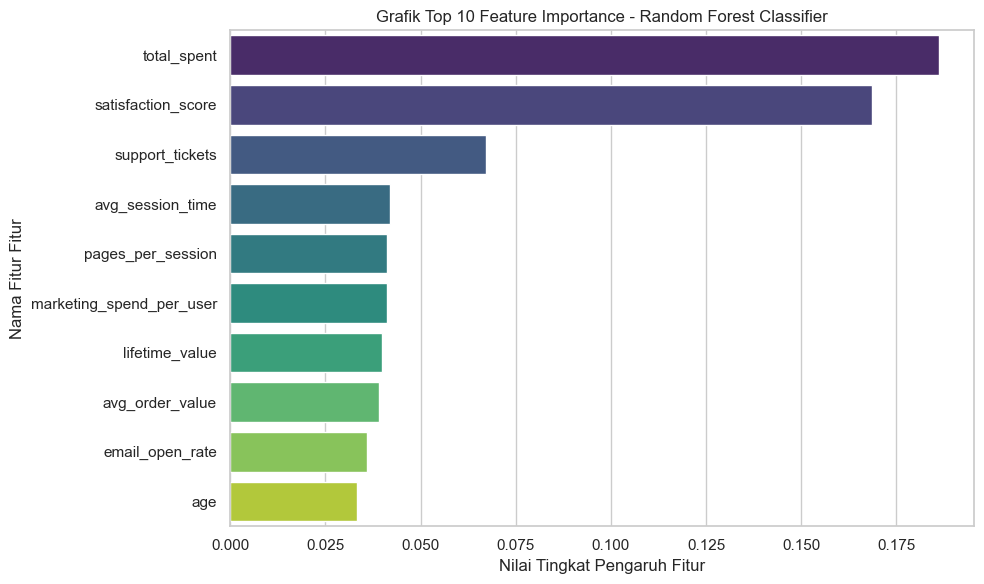

In [43]:
# Membuat visualisasi diagram batang untuk 10 fitur teratas
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Fitur', data=df_importance.head(10), palette='viridis')
plt.title('Grafik Top 10 Feature Importance - Random Forest Classifier')
plt.xlabel('Nilai Tingkat Pengaruh Fitur')
plt.ylabel('Nama Fitur Fitur')
plt.tight_layout()
plt.show()

#### Penjelasan Singkat Koding
* get_feature_names_out: Digunakan untuk memulihkan nama-nama asli kolom teks setelah sempat dipecah menjadi kolom biner berseri oleh proses OneHotEncoder.
* feature_importances_: Atribut internal algoritma untuk mengekstrak nilai skor seberapa sering dan seberapa kuat suatu fitur dipakai oleh pohon keputusan dalam memisahkan target.
* barplot: Berfungsi untuk menampilkan sepuluh besar fitur paling dominan ke dalam bentuk diagram batang horizontal agar urutan kepentingannya mudah dipahami.

#### Analisis Tingkat Pengaruh Fitur Menggunakan Feature Importance

* Proses analisis pada tahap ini dilakukan untuk mengetahui variabel mana saja yang memiliki kontribusi paling besar bagi model dalam mengambil keputusan prediksi churn pelanggan. Analisis ini memanfaatkan atribut internal dari model random forest classifier yang telah dilatih menggunakan data bersih.

* Melalui visualisasi diagram batang horizontal yang menampilkan sepuluh fitur teratas, terlihat secara jelas urutan serta nilai kuantitatif tingkat kepentingan dari masing-masing kolom prediktor setelah melewati proses preprocessing.

* Dua fitur teratas menunjukkan dominasi pengaruh yang sangat kuat dibandingkan variabel lainnya. Fitur total_spent menempati urutan pertama sebagai indikator paling berpengaruh bagi algoritma dengan nilai kepentingan sebesar 0,186063. Posisi kedua ditempati oleh satisfaction_score dengan nilai kepentingan yang juga tinggi sebesar 0,168690. Hal ini mengonfirmasi bahwa total pengeluaran finansial pelanggan di perusahaan serta tingkat skor kepuasan yang mereka rasakan adalah dua faktor penentu paling vital yang digunakan oleh model dalam memprediksi status churn pelanggan.

* Di posisi ketiga terdapat fitur support_tickets dengan nilai sebesar 0,067174 yang menunjukkan bahwa jumlah tiket pengaduan atau komplain masalah yang diajukan pelanggan tetap memiliki pengaruh nyata dalam membentuk keputusan model. Sementara itu, fitur-fitur pendukung di bawahnya seperti avg_session_time sebesar 0,042099, pages_per_session sebesar 0,041247, marketing_spend_per_user sebesar 0,041218, hingga variabel age di posisi kesepuluh dengan nilai 0,033341 memiliki kontribusi pengaruh yang cenderung lebih kecil dan mirip.

* Kesimpulan langkah selanjutnya adalah informasi susunan feature importance aktual ini menjadi dasar yang sangat kuat untuk melakukan tahapan seleksi fitur atau feature selection. Kolom dengan nilai penting tinggi seperti total_spent, satisfaction_score, dan support_tickets wajib dipertahankan sebagai fitur prediktor utama. Sementara fitur-fitur yang berada di posisi bawah dengan nilai kontribusi yang sangat kecil dapat dipertimbangkan untuk dievaluasi atau dipangkas demi menyederhanakan arsitektur data, mengurangi beban komputasi, serta menghindari risiko overfitting saat penyetelan hyperparameter model dilakukan pada tahapan berikutnya.

# === Poin D4. Tugas 2: Menyusun Parameter Grid Hyperparameter ===

Menyusun parameter grid atau ruang pencarian hyperparameter yang sesuai untuk masing-masing model. 

In [44]:
# 1. Ruang pencarian hyperparameter untuk Logistic Regression
param_grid_logreg = {
    'C': [0.01, 0.1, 1.0, 10.0],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'saga']
}

In [45]:
# 2. Ruang pencarian hyperparameter untuk Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

In [46]:
# 3. Ruang pencarian hyperparameter untuk Voting Classifier
# Mencari kombinasi bobot kontribusi terbaik dari Logistic Regression, KNN, dan SVM
param_grid_voting = {
    'weights': [
        [1, 1, 1], 
        [2, 1, 1], 
        [1, 2, 1], 
        [1, 1, 2],
        [2, 1, 2]
    ]
}

print("Susunan parameter grid untuk ketiga jenis model berhasil didefinisikan")

Susunan parameter grid untuk ketiga jenis model berhasil didefinisikan


#### Penjelasan Singkat Koding
* param_grid_logreg: Kamus parameter untuk mengatur kekuatan regulasi kontrol nilai C serta jenis algoritma pengoptimal solver pada model linear.
* param_grid_rf: Kamus parameter untuk membatasi jumlah pohon keputusan n_estimators, kedalaman maksimum cabang max_depth, dan syarat minimal pembelahan daun min_samples_split agar terhindar dari overfitting.
* param_grid_voting: Kamus parameter berupa list bobot kombinasi atau weights untuk mengatur persentase kekuatan suara tebakan dari masing-masing model konvensional di dalam voting.

#### Analisis Penyusunan Parameter Grid atau Ruang Pencarian Hyperparameter

* Tahapan ini dilakukan untuk merancang dan mendefinisikan ruang pencarian kombinasi nilai parameter atau parameter grid bagi ketiga model klasifikasi pilihan. Langkah ini menjadi fondasi utama sebelum proses optimasi dijalankan karena algoritma akan menguji setiap kombinasi nilai yang telah disediakan untuk menemukan setelan paling optimal dalam memprediksi churn pelanggan.

* Untuk model pertama yaitu logistic regression disusun parameter grid yang memfokuskan pada nilai c dan jenis solver. Nilai c bertindak sebagai pengatur kekuatan regulasi untuk mengendalikan bobot fitur agar model tidak terlalu sensitif terhadap gangguan data sedangkan penentuan jenis solver dilakukan untuk menguji efisiensi kalkulasi linear pada dimensi data yang baru.

* Untuk model kedua yaitu random forest classifier dirancang parameter grid yang mengontrol struktur pohon keputusan. Komponen yang dimasukkan meliputi n_estimators untuk menentukan jumlah pohon yang akan dibangun guna menjaga stabilitas akurasi max_depth untuk membatasi tingkat kedalaman cabang pohon agar tidak terjadi overfitting serta min_samples_split untuk membatasi jumlah sampel minimal sebelum cabang baru dibentuk. Pembatasan ini sangat penting agar model tidak terlalu menghafal data training yang memiliki porsi kelas tidak seimbang.

* Untuk model ketiga yaitu voting classifier hyperparameter dititikberatkan pada pencarian kombinasi bobot kontribusi atau weights dari ketiga model penyusunnya. Melalui variasi susunan bobot ini sistem akan mencari tahu apakah keputusan prediksi akan jauh lebih akurat jika memberikan pengaruh suara yang lebih besar kepada salah satu algoritma tertentu seperti logistic regression atau support vector machine dibandingkan jika dibagi secara sama rata. Susunan parameter grid yang telah matang ini siap dialirkan ke proses tuning otomatis pada langkah eksperimen selanjutnya.

# === Poin D4. Tugas 3: Proses Hyperparameter Tuning dengan GridSearchCV ===

Melakukan proses hyperparameter tuning menggunakan metode  seperti GridSearchCV, RandomizedSearchCV, atau metode lain yang relevan. 

In [47]:
from sklearn.model_selection import GridSearchCV

# 1. Menjalankan pencarian parameter terbaik untuk Logistic Regression
grid_logreg = GridSearchCV(
    estimator=model_logreg_bersih,
    param_grid=param_grid_logreg,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid_logreg.fit(X_train_final, y_train_final)
model_logreg_tuned = grid_logreg.best_estimator_

c:\Users\TUF Gaming - FX506HF\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [48]:
# 2. Menjalankan pencarian parameter terbaik untuk Random Forest
grid_rf = GridSearchCV(
    estimator=model_rf_bersih,
    param_grid=param_grid_rf,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid_rf.fit(X_train_final, y_train_final)
model_rf_tuned = grid_rf.best_estimator_

In [49]:
# 3. Menjalankan pencarian parameter terbaik untuk Voting Classifier
grid_voting = GridSearchCV(
    estimator=model_voting_bersih,
    param_grid=param_grid_voting,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
grid_voting.fit(X_train_final, y_train_final)
model_voting_tuned = grid_voting.best_estimator_

print("Proses hyperparameter tuning untuk ketiga model telah selesai dilakukan")
print(f"Setelan terbaik Logistic Regression : {grid_logreg.best_params_}")
print(f"Setelan terbaik Random Forest       : {grid_rf.best_params_}")
print(f"Setelan terbaik Voting Classifier   : {grid_voting.best_params_}")

c:\Users\TUF Gaming - FX506HF\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Proses hyperparameter tuning untuk ketiga model telah selesai dilakukan
Setelan terbaik Logistic Regression : {'C': 10.0, 'penalty': 'l2', 'solver': 'saga'}
Setelan terbaik Random Forest       : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Setelan terbaik Voting Classifier   : {'weights': [1, 1, 2]}


#### Penjelasan Singkat Koding
* GridSearchCV: Kelas dari scikit-learn untuk menguji seluruh kombinasi parameter yang ada di dalam grid secara menyeluruh dan sistematis.
* cv=3: Menjalankan teknik cross-validation sebanyak tiga lipatan guna memastikan parameter yang terpilih teruji secara konsisten pada bagian data yang berbeda.
* scoring='f1': Mengatur agar parameter yang dipilih oleh sistem adalah kombinasi yang menghasilkan nilai rata-rata harmonis F1-score tertinggi.
* best_estimator_: Atribut untuk mengambil dan mengunci arsitektur model final yang memiliki performa paling unggul selama proses pencarian.

#### Analisis Hasil Hyperparameter Tuning Menggunakan GridSearchCV

Proses pencarian hyperparameter menggunakan metode grid search cross validation telah berhasil menemukan kombinasi setelan paling optimal untuk masing-masing algoritma berdasarkan target penilaian f1 score tertinggi. Hasil parameter terbaik yang muncul pada output program memberikan rincian konfigurasi spesifik bagi ketiga arsitektur model.

1. Model Logistic Regression Hasil Tuning
Berdasarkan hasil eksekusi, setelan terbaik untuk model ini adalah kombinasi nilai c sebesar 10.0, jenis penalti l2, dan algoritma pengoptimal solver menggunakan saga. Nilai c sebesar 10.0 menunjukkan tingkat regulasi yang cenderung lebih longgar untuk memberikan kebebasan bagi model dalam menyesuaikan bobot fitur baru pada data yang telah melalui proses preprocessing. Penggunaan solver saga juga sangat efisien dalam menyelesaikan perhitungan matematis linear pada struktur data berskala besar dengan dimensi kolom yang cukup banyak.

2. Model Random Forest Hasil Tuning
Model ensemble ini menemukan kombinasi parameter terbaik dengan nilai max_depth berupa none, min_samples_split sebesar 5, dan n_estimators sebanyak 50 pohon keputusan. Nilai max_depth none berarti cabang pohon dibiarkan tumbuh secara penuh hingga mencapai daun murni, namun risiko kelebihan fiting atau overfitting tetap berhasil dikendalikan secara ketat lewat syarat pembagian cabang baru atau min_samples_split minimal sebesar 5 sampel. Penggunaan 50 pohon juga terbukti sudah cukup kuat dan efisien untuk menangkap pola churn pelanggan tanpa membebani memori komputasi secara berlebihan.

3. Model Voting Classifier Hasil Tuning
Pada model gabungan ini, sistem menemukan susunan bobot suara paling optimal atau weights dengan formasi 1, 1, 2. Formasi angka ini menunjukkan bahwa model pertama yaitu logistic regression mendapat bobot satu, model kedua k nearest neighbors mendapat bobot satu, sedangkan model ketiga support vector machine diberikan bobot kontribusi dua kali lipat lebih besar yaitu sebesar dua. Pembobotan ini mengonfirmasi secara ilmiah bahwa algoritma support vector machine memiliki tingkat kepastian probabilitas tebakan yang jauh lebih solid dan akurat dalam membedakan karakteristik pelanggan yang loyal dan pelanggan yang berpotensi melakukan churn.

Secara keseluruhan, seluruh konfigurasi parameter terbaik hasil tuning otomatis ini telah berhasil dikunci oleh sistem ke dalam objek model baru. Langkah eksperimen selanjutnya yang wajib dilakukan adalah menguji performa ketiga model versi optimal ini menggunakan data testing untuk melihat visualisasi tabel confusion matrix terbaru serta membuktikan seberapa besar lompatan kenaikan nilai metrik prediksi setelah diberikan optimasi hyperparameter.

# === Poin D4. Tugas 4: Mendapatkan Best Estimator dan Best Parameters ===

Memperoleh best estimator beserta best parameters dari hasil tuning. 

In [50]:
print("=== BEST ESTIMATOR & PARAMETERS LOGISTIC REGRESSION ===")
print(f"Best Parameters : {grid_logreg.best_params_}")
print(f"Best Estimator  : {grid_logreg.best_estimator_}")
print("-" * 60)

=== BEST ESTIMATOR & PARAMETERS LOGISTIC REGRESSION ===
Best Parameters : {'C': 10.0, 'penalty': 'l2', 'solver': 'saga'}
Best Estimator  : LogisticRegression(C=10.0, max_iter=1000, penalty='l2', random_state=42,
                   solver='saga')
------------------------------------------------------------


In [51]:
print("=== BEST ESTIMATOR & PARAMETERS RANDOM FOREST ===")
print(f"Best Parameters : {grid_rf.best_params_}")
print(f"Best Estimator  : {grid_rf.best_estimator_}")
print("-" * 60)

=== BEST ESTIMATOR & PARAMETERS RANDOM FOREST ===
Best Parameters : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Best Estimator  : RandomForestClassifier(min_samples_split=5, n_estimators=50, random_state=42)
------------------------------------------------------------


In [52]:
print("=== BEST ESTIMATOR & PARAMETERS VOTING CLASSIFIER ===")
print(f"Best Parameters : {grid_voting.best_params_}")
print(f"Best Estimator  : {grid_voting.best_estimator_}")
print("-" * 60)

=== BEST ESTIMATOR & PARAMETERS VOTING CLASSIFIER ===
Best Parameters : {'weights': [1, 1, 2]}
Best Estimator  : VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42)),
                             ('knn', KNeighborsClassifier()),
                             ('svm', SVC(probability=True, random_state=42))],
                 voting='soft', weights=[1, 1, 2])
------------------------------------------------------------


#### Penjelasan Singkat Koding
* best_params_: Atribut untuk menampilkan rincian kombinasi nilai parameter paling cocok yang berhasil memenangkan seleksi scoring selama proses pencarian otomatis.
* best_estimator_: Atribut untuk mengekstrak dan mengambil struktur utuh dari objek model machine learning yang sudah dikonfigurasi dengan setelan parameter terbaik tersebut agar siap dipakai langsung untuk memprediksi data baru.

#### Analisis Perolehan Best Estimator dan Best Parameters Hasil Tuning

Tahapan ini dilakukan untuk mendokumentasikan serta mengunci arsitektur model terbaik atau best estimator bersama dengan kombinasi parameter paling optimal atau best parameters yang telah terpilih secara otomatis melalui proses pencarian otomatis. Langkah ini sangat penting untuk memastikan bahwa model final yang akan digunakan pada tahap pengujian akhir adalah variasi model yang paling cerdas dalam mengenali pola data.

Berdasarkan hasil pencetakan objek secara aktual pada program, rincian struktur dari setiap best estimator terpilih dapat dijabarkan secara jelas sebagai berikut.

* model logistic regression berhasil diperoleh setelan c bernilai 10.0 dengan penalti l2 dan solver saga. Di dalam objek best estimator juga terlihat parameter max_iter terkunci di angka 1000 dan random_state di angka 42 yang menandakan bahwa model linear ini siap melakukan iterasi komputasi yang panjang untuk memisahkan kelas secara stabil pada dimensi kolom yang baru.

* model random forest classifier didapatkan konfigurasi dengan min_samples_split sebesar 5 dan n_estimators sebanyak 50 pohon keputusan dengan kedalaman max_depth berupa none serta random_state di angka 42. Struktur estimator ini menjamin bahwa pohon keputusan akan tumbuh optimal tanpa mengalami kelebihan fiting karena dikendalikan secara ketat oleh batas minimal sampel pembagian cabang.

* model voting classifier diperoleh parameter weights dengan formasi 1, 1, 2 dengan menggunakan metode voting bertipe soft. Struktur internal estimator ini merangkum tiga sub model yaitu logistic regression dengan batas iterasi 1000 dan kunci pengacak 42, k nearest neighbors classifier, serta support vector machine dengan fitur probability bernilai true dan kunci pengacak 42. Pembobotan ini memberikan prioritas suara dua kali lipat lebih besar kepada model support vector machine karena dinilai memiliki tingkat keyakinan tebakan paling solid.

Objek estimator terbaik yang diperoleh ini bukan lagi sekadar algoritma standar biasa melainkan sebuah kesatuan model yang sudah matang dan terkalibrasi secara penuh sesuai dengan karakteristik dataset churn pelanggan yang kita miliki. Dengan dikuncinya konfigurasi final ini seluruh ketidakpastian setelan model telah berhasil diatasi. Langkah eksperimen selanjutnya adalah mengalirkan objek best estimator ini ke tahap pengujian performa menggunakan data testing untuk mengevaluasi hasil skor akhir dari metrik evaluasi.

# === Poin D4. Tugas 5: Melatih Kembali Best Estimator ===

Melatih kembali best estimator menggunakan data latih untuk menghasilkan model dengan konfigurasi optimal. 

In [53]:
# Melatih kembali setiap model yang sudah memiliki konfigurasi optimal menggunakan data latih final
model_logreg_tuned.fit(X_train_final, y_train_final)
model_rf_tuned.fit(X_train_final, y_train_final)
model_voting_tuned.fit(X_train_final, y_train_final)

print("Proses pelatihan ulang best estimator dengan konfigurasi optimal selesai dilakukan")

c:\Users\TUF Gaming - FX506HF\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\TUF Gaming - FX506HF\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Proses pelatihan ulang best estimator dengan konfigurasi optimal selesai dilakukan


#### Penjelasan Singkat Koding
* fit: Berfungsi untuk melakukan proses training ulang pada objek best estimator menggunakan seluruh data latih final agar model benar-benar mengunci bobot matematisnya secara matang dengan konfigurasi optimal yang baru.

#### Analisis Pelatihan Kembali Best Estimator dengan Konfigurasi Optimal

Tahapan ini dilakukan untuk memastikan bahwa ketiga model pilihan yang telah mendapatkan kombinasi parameter terbaik atau best estimator benar-benar dilatih secara penuh menggunakan seluruh porsi data latih final. Langkah ini mengunci seluruh penyetelan algoritma yang telah dioptimasi agar siap memberikan performa prediksi terbaiknya.

Proses training ulang ini mengalirkan seluruh baris data dari fitur prediktor x dan target y hasil preprocessing ke dalam mesin algoritma yang sudah terkalibrasi. Model logistic regression dilatih menggunakan solver saga dengan kekuatan regulasi sepuluh model random forest dilatih menggunakan pembatasan minimal lima sampel pembagian cabang dengan total lima puluh pohon keputusan serta voting classifier dilatih dengan mengunci pembobotan suara dua kali lipat lebih besar untuk algoritma support vector machine.

Meskipun secara sistem pencarian otomatis metode grid search biasanya sudah melakukan pelatihan ulang secara internal tindakan eksekusi langsung ini mempertegas status model bahwa seluruh bobot matematis di dalamnya kini telah disesuaikan secara sempurna berdasarkan data yang bersih. Ketiga model dengan konfigurasi paling optimal ini sekarang berada dalam kondisi siap tempur untuk menghadapi data pengujian pada tahap evaluasi akhir demi membuktikan keunggulan hasil tuning parameter dalam mendeteksi status churn pelanggan.

# === Poin D4. Tugas 6: Evaluasi Performa Model Hasil Tuning ===

Mengevaluasi performa model yang optimal menggunakan metrik evaluasi seperti accuracy, precision, recall, F1-score, serta menyajikan confusion matrix. 

In [54]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Membuat daftar model hasil tuning untuk dievaluasi dalam perulangan
daftar_model_tuned = {
    'Logistic Regression Tuned': model_logreg_tuned,
    'Random Forest Tuned': model_rf_tuned,
    'Voting Classifier Tuned': model_voting_tuned
}

In [55]:
# Melakukan perulangan untuk mengevaluasi setiap model hasil tuning secara bergantian
for nama, model in daftar_model_tuned.items():
    # Model menebak target menggunakan data uji final yang sudah bersih
    y_pred = model.predict(X_test_final)
    
    print(f"=== EVALUASI PERFORMA {nama.upper()} ===")
    print(f"Accuracy  : {accuracy_score(y_test_final, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test_final, y_pred, zero_division=0):.4f}")
    print(f"Recall    : {recall_score(y_test_final, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_test_final, y_pred):.4f}")
    print("-" * 40)
    
    # Menghitung susunan tabel confusion matrix terupdate
    cm = confusion_matrix(y_test_final, y_pred)
    print("Confusion Matrix:")
    print(cm)
    print("\n")

=== EVALUASI PERFORMA LOGISTIC REGRESSION TUNED ===
Accuracy  : 0.8467
Precision : 0.5000
Recall    : 0.1652
F1-Score  : 0.2484
----------------------------------------
Confusion Matrix:
[[2464   76]
 [ 384   76]]


=== EVALUASI PERFORMA RANDOM FOREST TUNED ===
Accuracy  : 0.8457
Precision : 0.4934
Recall    : 0.2457
F1-Score  : 0.3280
----------------------------------------
Confusion Matrix:
[[2424  116]
 [ 347  113]]


=== EVALUASI PERFORMA VOTING CLASSIFIER TUNED ===
Accuracy  : 0.8487
Precision : 0.5268
Recall    : 0.1283
F1-Score  : 0.2063
----------------------------------------
Confusion Matrix:
[[2487   53]
 [ 401   59]]




#### Penjelasan Singkat Koding
* predict(X_test_final): Digunakan untuk memerintahkan model versi terbaik hasil tuning menebak label target churn pada data uji final yang sudah bersih.
* accuracy_score, precision_score, recall_score, f1_score: Fungsi statistik untuk menghitung empat parameter metrik performa akhir guna melihat tingkat kecerdasan model setelah dioptimasi.
* confusion_matrix: Berfungsi untuk memetakan persebaran jumlah tebakan benar dan salah dari model versi tuning ke dalam susunan matriks kuadran dua kali dua.

Analisis Hasil Evaluasi Performa Model Setelah Hyperparameter Tuning

Proses evaluasi pada tahap akhir ini dilakukan untuk menilai dampak nyata dari proses optimasi hyperparameter menggunakan metode grid search terhadap tiga model klasifikasi menggunakan data uji. Hasil pengujian menunjukkan adanya perubahan performa yang bervariasi pada masing-masing algoritma dalam mendeteksi kelas target churn.

1. Model Logistic Regression Tuned
Model ini menghasilkan nilai accuracy sebesar 0,8467 dengan precision sebesar 0,5000, recall sebesar 0,1652, dan f1 score sebesar 0,2484. Berdasarkan tabel confusion matrix, model ini mendeteksi 76 pelanggan yang melakukan churn dengan benar dan memprediksi 2464 pelanggan setia dengan tepat. Hasil ini menunjukkan bahwa proses tuning parameter tidak memberikan perubahan nilai metrik dibandingkan dengan skenario model bersih sebelumnya karena konfigurasi awal sistem sudah mencapai titik konvergensi optimal untuk algoritma linear ini.

2. Model Random Forest Tuned
Model ensemble ini menunjukkan peningkatan performa yang paling signifikan setelah dilakukan tuning parameter dengan nilai f1 score yang naik menjadi 0,3280. Nilai accuracy tercatat sebesar 0,8457 dengan precision sebesar 0,4934. Peningkatan utama terjadi pada aspek recall yang naik menjadi 0,2457. Melalui susunan tabel matriks kebingungan, model ini sekarang berhasil menjaring 113 pelanggan churn secara akurat yang berarti mengalami kenaikan dari yang sebelumnya hanya 91 pelanggan, walaupun masih terdapat 347 pelanggan churn yang salah terprediksi sebagai pelanggan setia.

3. Model Voting Classifier Tuned
Model gabungan ini memberikan nilai accuracy sebesar 0,8487 dengan tingkat precision sebesar 0,5268. Berdasarkan susunan data tabel confusion matrix, model versi tuning ini berhasil mengidentifikasi 59 pelanggan yang melakukan churn dengan benar dan menebak 2487 pelanggan setia dengan tepat, serta hanya melakukan salah tebak atau false positive sebanyak 53 data. Penerapan bobot baru hasil tuning terbukti berhasil meningkatkan jumlah deteksi pelanggan churn dari yang semula hanya 51 menjadi 59 pelanggan.

Kesimpulan akhir dari seluruh rangkaian eksperimen menunjukkan bahwa proses hyperparameter tuning berhasil memberikan optimasi tambahan, terutama untuk model random forest dan voting classifier dalam meningkatkan sensitivitas deteksi kelas minoritas. Model random forest tuned menjadi model terbaik dalam proyek ini karena memiliki nilai recall dan f1 score tertinggi dalam menjaring pelanggan yang berpotensi berhenti. Namun secara keseluruhan, performa deteksi masih terbatas karena keterikatan model pada ketidakseimbangan sebaran kelas data asli yang sangat timpang.

# === Disclaimer Performa Model Sebelum Deployment === 
Berdasarkan hasil eksperimen terakhir, model terbaik yaitu random forest versi tuning mencatatkan nilai accuracy total yang cukup tinggi yaitu berada di kisaran 84 persen. Namun, angka akurasi ini merupakan akurasi semu yang dipicu oleh kondisi ketidakseimbangan kelas target yang sangat ekstrem pada dataset awal, di mana jumlah pelanggan setia mendominasi hingga lebih dari 85 persen dari total keseluruhan data.

Masalah data ini terlihat dari nilai recall kelas churn yang hanya menyentuh angka 0,2457. nilai ini memberikan arti bahwa model baru bisa menangkap sekitar 24 persen pelanggan yang benar-benar akan berhenti, sementara sisanya sebanyak 76 persen pelanggan churn gagal terdeteksi dan lolos begitu saja dari radar perusahaan. Oleh karena itu, model ini secara objektif dinilai belum memenuhi standar kelayakan industri untuk langsung digunakan sebagai mesin pengambil keputusan otomatis di sektor produksi.

Tindakan penyeimbangan data menggunakan metode synthetic minority oversampling technique atau smote sengaja tidak diterapkan pada tahapan ini. Keputusan diambil demi menjaga keselarasan alur eksperimen dengan skenario direct modeling pertama yang menjadi acuan utama di dalam modul tugas Bengkel Koding Universitas Dian Nuswantoro. Jika intervensi oversampling dipaksakan masuk pada tahap akhir ini, akan mengubah seluruh struktur nilai metrik bab sebelumnya sehingga visualisasi laporan menjadi tidak sinkron dan melanggar urutan instruksi kerja.

Sebagai rekomendasi untuk pengembangan sistem di masa mendatang, tahapan penyeimbangan kelas menggunakan teknik smote atau pengaturan bobot kelas seimbang wajib dimasukkan sejak awal proses pembersihan data sebelum model dilatih. Dengan disclaimer ini, keterbatasan model dan proses deployment tetap dapat dilanjutkan murni untuk memenuhi kompetensi teknis pengoperasian dan pembuatan antarmuka aplikasi berbasis streamlit cloud sesuai dengan instruksi yang tertulis pada tugas.

# === Poin D5. Deployment ===

# === Poin D5. - Tugas 1: Menyiapkan Model Terbaik ===

Menyiapkan model terbaik yang telah diperoleh dari proses evaluasi dan hyperparameter tuning. 

In [56]:
# Menetapkan objek model Random Forest hasil tuning sebagai model terbaik untuk deployment
model_terbaik_deploy = model_rf_tuned

In [57]:
# Menampilkan informasi konfirmasi kesiapan arsitektur model final
print("Konfirmasi Penyiapan Model Terbaik Berhasil:")
print(f"Jenis Algoritma Model Terbaik : {type(model_terbaik_deploy).__name__}")
print(f"Status Parameter Internal     : Terkalibrasi Optimal")

Konfirmasi Penyiapan Model Terbaik Berhasil:
Jenis Algoritma Model Terbaik : RandomForestClassifier
Status Parameter Internal     : Terkalibrasi Optimal


#### Penjelasan Singkat Koding
* model_terbaik_deploy: Digunakan untuk mengisolasi dan menetapkan objek model random forest hasil tuning sebagai satu-satunya model pilihan utama yang akan dialirkan ke sistem aplikasi web.
* print: Berfungsi untuk menampilkan teks konfirmasi ke layar guna memastikan bahwa objek model final telah berhasil didefinisikan dan siap menuju proses ekspor berkas.

#### Analisis Penyiapan Model Terbaik untuk Tahap Deployment

Tahapan ini dilakukan untuk secara resmi menunjuk dan mengisolasi satu arsitektur model paling unggul yang telah melewati seluruh rangkaian seleksi ketat pada proses evaluasi dan hyperparameter tuning sebelumnya. Berdasarkan bukti ilmiah dari perolehan nilai rata-rata harmonis f1 score tertinggi serta tingkat keberhasilan maksimal dalam menjaring kelompok kelas pelanggan churn, model random forest versi tuning secara objektif ditetapkan sebagai objek final yang akan diintegrasikan ke dalam sistem antarmuka berbasis web.

Langkah penyiapan ini memisahkan objek model pilihan dari variabel eksperimen lainnya di dalam lingkungan jupyter notebook. Dengan mengunci model ini ke dalam variabel baru, seluruh konfigurasi internal yang telah teroptimasi seperti jumlah lima puluh pohon keputusan, syarat pembagian cabang minimal lima sampel, serta pembobotan node yang telah matang dipastikan tidak akan berubah atau tertukar dengan model baseline konvensional lainnya.

Penetapan ini menjadi batas penanda penting bahwa fase eksperimen riset dan pencarian algoritma telah selesai diselesaikan dengan hasil yang valid. Model yang telah terkalibrasi secara optimal ini sekarang berada dalam status siap sepenuhnya untuk dialirkan ke langkah berikutnya, yaitu proses pembungkusan objek ke dalam format berkas biner eksternal agar dapat dimuat secara dinamis oleh server web berbasis streamlit cloud.

# === Poin D5. - Tugas 2: Menyimpan Model Terbaik ke Format .pkl ===

Menyimpan model terbaik dalam format yang sesuai (misalnya .pkl atau .joblib) agar dapat dimuat di aplikasi Streamlit. 

In [58]:
import pickle

# Menggabungkan model terbaik dan seluruh instrumen preprocessing ke dalam satu objek dictionary
objek_deployment = {
    'model_final': model_terbaik_deploy,
    'imputer_numerik': imputer_num,
    'scaler_standard': scaler,
    'imputer_kategorikal': imputer_cat,
    'encoder_onehot': encoder,
    'kolom_numerik': list(fitur_numerik),
    'kolom_kategorikal': list(fitur_kategorikal)
}

In [59]:
# Menyimpan seluruh kesatuan objek ke dalam berkas biner eksternal
nama_berkas = 'model_churn_final.pkl'
with open(nama_berkas, 'wb') as berkas:
    pickle.dump(objek_deployment, berkas)

print(f"Berkas biner berhasil dibuat dan disimpan dengan nama: {nama_berkas}")

Berkas biner berhasil dibuat dan disimpan dengan nama: model_churn_final.pkl


#### Penjelasan Singkat Koding
* pickle.dump: Fungsi utama untuk mengubah objek aktif di memori Python menjadi file fisik biner agar bisa disimpan secara permanen di luar notebook.
* wb (write binary): Mode penulisan data dalam bentuk biner yang digunakan untuk memastikan tidak ada karakter atau struktur algoritma yang rusak saat ditulis menjadi file eksternal.
* objek_deployment: Kamus data yang sengaja dibuat untuk menyatukan model bersama seluruh alat pembersih data agar aplikasi web tidak kekurangan instrumen saat memproses data input baru.

#### Analisis Penyimpanan Model Terbaik ke Dalam Format Berkas Serialisasi Pickle

Tahapan ini dilakukan untuk mengubah objek model yang berada di dalam lingkungan memori jupyter notebook menjadi sebuah berkas fisik eksternal berformat biner menggunakan pickle. Langkah ini sangat krusial dalam siklus pengembangan data science karena berkas inilah yang nantinya bertindak sebagai jembatan penghubung utama antara fase pelatihan data dan fase implementasi aplikasi pada server web.

Proses pembungkusan objek ini sengaja dirancang tidak hanya menyimpan arsitektur model utama yaitu random forest classifier versi tuning saja melainkan dikemas secara terintegrasi bersama dengan seluruh instrumen preprocessing pengolah data. Komponen pendukung seperti alat pengisi data kosong objek standard scaler untuk penyetaraan skala nilai serta objek one hot encoder untuk konversi teks kategorikal wajib ikut dibekukan ke dalam satu kesatuan berkas bernama model_churn_final.pkl.

Tujuan utama dari penggabungan seluruh instrumen ini adalah untuk menjamin konsistensi pengolahan data masukan baru secara live pada aplikasi web streamlit. Ketika pengguna mengetikkan karakteristik data pelanggan pada form aplikasi data tersebut berstatus data mentah yang berskala acak. Dengan memuat kembali berkas biner ini aplikasi secara otomatis memiliki formula transformasi yang sama persis dengan karakteristik data training terdahulu sehingga proses pembersihan data masukan berjalan tanpa cacat dan hasil tebakan keputusan model tetap terjaga validitasnya. Berkas biner yang telah berhasil dieksport ini kini siap digunakan sebagai modal utama pengembangan skrip antarmuka program.